# Donut 도면(Drawing) 파인튜닝 노트북

`donut_training.ipynb`(영수증/CORD용)를 **기계 도면 표제란 정보 추출** 태스크(도면 요소 추출)에 맞게 변형한 노트북입니다.

- 입력: `data/drawings/images/*.png` (도면 이미지)
- 정답: `data/drawings/labels/*.json` (도면번호/재질/공차/볼트홀 등 스키마)
- 태스크 토큰: **`<s_drawing>`** 
- 베이스 모델: `naver-clova-ix/donut-base` (영수증 파인튜닝본이 아님)
- 학습 출력: `checkpoints_drawings/` (영수증 체크포인트와 분리)

> ⚠️ **데이터가 적습니다(≈50장).** Donut 기준으로는 매우 작은 규모라 데모/PoC 수준입니다.
> 실사용 품질을 원하면 도면 수를 늘리고 라벨의 빈 값을 최대한 채우세요.

### 실행 순서
1. 환경 확인 → 2. 설정(CFG) → 3. 라벨 점검 → 4. 데이터 분리 →
5. 모델 로드 → 6. 데이터셋 구성 → 7. 학습 → 8. 평가 → 9. 추론


## Donut 파인튜닝 과정 상세 설명

---

### 1. 전체 흐름 한눈에 보기

```
    [이미지 입력]                     [정답 JSON]
           │                               │
           ▼                               ▼
  ┌─────────────────┐           ┌──────────────────┐
  │  DonutProcessor │           │   json2token()   │
  │  resize / norm  │           │   dict → token   │
  └────────┬────────┘           └────────┬─────────┘
           │ pixel_values                │ target_seq
           └──────────────┬──────────────┘
                          ▼
       ╔══════════════════════════════════════╗
       ║      VisionEncoderDecoderModel       ║
       ║                                      ║
       ║  ┌─────────────────┐  ┌───────────┐  ║
       ║  │     Swin-T      │─▶│   BART    │  ║
       ║  │    (Encoder)    │  │ (Decoder) │  ║
       ║  └─────────────────┘  └─────┬─────┘  ║
       ╚═════════════════════════════╧════════╝
                                     │ logits
                                     ▼
                           CrossEntropyLoss
                                     │
                                     ▼
                          역전파 / 가중치 업데이트
```

---

### 2. 각 구성 요소 역할

| 구성 요소 | 역할 | 출력 형태 |
|:---|:---|:---|
| **DonutProcessor** | 이미지 리사이즈 → `[1280×960]`, 픽셀 정규화 `[-1, 1]` | `(C, H, W)` 텐서 |
| **Swin Transformer** | 이미지를 패치 단위로 분석, 시각적 특징 추출 | `(seq_len, hidden_dim)` |
| **BART Decoder** | 인코더 feature + 이전 토큰 → 다음 토큰 예측 | 토큰 시퀀스 |
| **json2token()** | Python dict → `<s_key>value</s_key>` XML 형식 변환 | 문자열 |
| **token2json()** | 생성된 토큰 시퀀스 → Python dict 역변환 | dict |

---

### 3. Teacher Forcing — 학습 방식

| 구분 | 추론 시 (자유 생성) | 학습 시 (Teacher Forcing) |
|:---:|:---|:---|
| **다음 입력** | 이전 **예측** 토큰 사용 | 이전 **정답** 토큰 사용 |
| **특징** | 오류가 누적될 수 있음 | 안정적이고 빠른 학습 |
| **예시** | `<s_total>` → `1200` → ... (틀려도 진행) | `<s_total>` → `12500` → ... (항상 정답 제공) |

---

### 4. Loss 계산 — 모델이 무엇을 배우는가

```python
# 정답 레이블 (labels)
[<s_total>, 1, 2, 5, 0, 0, </s_total>, PAD, PAD ...]
    →  token ids: [102, 49, 50, 53, 48, 48, 103, -100, -100 ...]
                                                  ^^^^^^^^^^^^
                                            패딩: -100으로 마스킹 → loss 제외

# CrossEntropyLoss
loss = -log(P(정답 토큰))     # 정답 토큰의 예측 확률이 높을수록 loss 감소
```

> **핵심:** loss가 낮아진다 = 모델이 정답 토큰을 더 높은 확률로 예측하게 됨

---

### 5. 파인튜닝 vs 처음부터 학습 (From Scratch)

| 항목 | ✅ 파인튜닝 | ❌ From Scratch |
|:---|:---:|:---:|
| 시작 가중치 | 사전학습 완료 (문서 이해 능력 보유) | 랜덤 초기화 |
| 필요 데이터 | 수백 ~ 수천 장 | 수십만 장 이상 |
| 학습 시간 | 수 시간 ~ 수 일 | 수 주 ~ 수 개월 |
| GPU 비용 | 낮음 | 매우 높음 |
| 권장 상황 | **대부분의 실무** | 완전히 새로운 도메인 |

> **결론:** 실무에서는 거의 항상 파인튜닝을 사용합니다.

---

### 6. 학습 중 모니터링 지표

| 지표 | 의미 | 정상 패턴 | 이상 신호 |
|:---|:---|:---:|:---:|
| `train_loss` | 학습 데이터 오차 | 지속 감소 ↘ | 감소 없이 진동 |
| `eval_loss` | 검증 데이터 오차 | 감소 후 수렴 | **증가 시작** → 과적합 |
| `grad_norm` | 그래디언트 크기 | 안정적 유지 | 급격히 증가 → 폭발 |

```
loss
  │
8 │ ╲
6 │  ╲
4 │   ╲──╮
2 │      ╰──────────── ← 수렴 (이상적)
  │                  ╰── eval_loss 증가 시 → 과적합
  └──────────────────────────────── step
     초기 급감        수렴 구간
```

**과적합 방지 설정:**
- `save_total_limit=3` — 최신 체크포인트 3개만 유지
- `load_best_model_at_end=True` — 학습 종료 후 eval_loss 최저 모델 자동 복원

> 🔹 **환경 점검** — 위젯 렌더러 비활성화 및 PyTorch/Transformers 버전·GPU(CUDA) 상태 확인

In [1]:
# ── widget 렌더러 오류 방지 (VS Code Jupyter) ─────────────────────
# tqdm.auto 및 HuggingFace 내부 progress bar가 ipywidget을
# 사용하지 않도록 강제합니다 — 텍스트 모드로 출력됩니다.
import os
os.environ['TQDM_NOTEBOOK'] = 'false'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'  # tokenizer 경고 억제

# ── Step 0: 환경 확인 ──────────────────────────────────────────────
# 학습에 필요한 라이브러리 버전과 GPU 상태를 먼저 점검합니다.
# CUDA가 False이면 GPU를 인식하지 못한 것 — 드라이버/환경을 확인하세요.
import torch
import transformers
import platform

print(f"Python     : {platform.python_version()}")
print(f"PyTorch    : {torch.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"CUDA 사용   : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU        : {torch.cuda.get_device_name(0)}")
    print(f"VRAM       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


/home/jhkim/anaconda3/envs/donut_vml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python     : 3.10.20
PyTorch    : 2.11.0+cu128
Transformers: 5.12.1
CUDA 사용   : True
GPU        : NVIDIA GeForce RTX 5090
VRAM       : 33.7 GB


> 🔹 필수 패키지(datasets·sentencepiece) 설치 확인 및 자동 설치

In [2]:
# ── 필수 패키지 설치 확인 ─────────────────────────────────────────
# 이미 설치된 경우 무시됩니다 — 매번 실행해도 안전합니다.
# datasets  : HuggingFace 데이터셋 다운로드 라이브러리
# sentencepiece : Donut 토크나이저가 내부적으로 사용하는 형태소 분석기
import importlib, subprocess, sys

required = {"datasets": "datasets", "sentencepiece": "sentencepiece"}
missing  = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]

if missing:
    print(f"설치 중: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing, "-q"])
    print("설치 완료 — 커널을 재시작하지 않아도 됩니다.")
else:
    print("모든 패키지 설치 확인 ✓")


모든 패키지 설치 확인 ✓


> 🔹 공통 라이브러리 import (json·torch·PIL·transformers Donut 등)

In [3]:
# ── 공통 Import ───────────────────────────────────────────────────
import json       # JSON 파일 읽기/쓰기
import os         # 파일 경로, 디렉터리 생성
import random     # 데이터셋 셔플 및 시드 고정
import re         # 정규표현식 (토큰 파싱에 사용)
import shutil
import tempfile
from pathlib import Path  # 운영체제 독립적인 파일 경로 처리

import numpy as np         # 수치 연산 및 시드 고정
from PIL import Image      # 이미지 파일 열기/변환
# tqdm.auto는 VS Code Jupyter에서 ipywidget 오류를 유발하므로 tqdm 직접 사용
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader  # 커스텀 데이터셋 클래스

from transformers import (
    DonutProcessor,              # 이미지 전처리 + 텍스트 토크나이저 통합 유틸리티
    VisionEncoderDecoderModel,   # 인코더(Swin-T) + 디코더(BART) 통합 모델
    Seq2SeqTrainer,              # Seq2Seq 학습 자동화 (forward/backward/저장)
    Seq2SeqTrainingArguments,    # 학습 하이퍼파라미터 설정
)

# ── matplotlib 전역 스타일 설정 ────────────────────────────────────
# VS Code Jupyter 인라인 표시 보장 (없으면 plt.show()가 no-op일 수 있음)
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({
    "figure.facecolor": "white",   # 그림 배경 흰색
    "axes.facecolor":   "white",   # 축 영역 배경 흰색
    "savefig.facecolor":"white",   # 저장 시에도 흰 배경
    "text.color":       "black",   # 모든 텍스트 검정
    "axes.labelcolor":  "black",   # 축 레이블 검정
    "xtick.color":      "black",   # x축 눈금 검정
    "ytick.color":      "black",   # y축 눈금 검정
    "axes.edgecolor":   "black",   # 축 테두리 검정
})

# ── 한글 폰트 설정 (plot 한글 깨짐 / Glyph 경고 방지) ──────────────
# 시스템의 Noto Sans CJK(KR 포함)를 등록해 matplotlib 기본 폰트로 사용
from matplotlib import font_manager as _fm
_ko_font = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
try:
    _fm.fontManager.addfont(_ko_font)
    matplotlib.rcParams["font.family"] = _fm.FontProperties(fname=_ko_font).get_name()
except Exception as _e:
    print("한글 폰트 등록 실패(영문만 표시됨):", _e)
matplotlib.rcParams["axes.unicode_minus"] = False   # 마이너스 기호 깨짐 방지

print("Import 완료 ✓  (한글 폰트:", matplotlib.rcParams["font.family"], ")")


한글 폰트 등록 실패(영문만 표시됨): [Errno 2] No such file or directory: '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'
Import 완료 ✓  (한글 폰트: ['sans-serif'] )


## Step 1 – 설정 (Configuration)

모든 하이퍼파라미터를 딕셔너리로 관리합니다.  
`dataset_name`을 `None`으로 바꾸고 `local_train_dir` / `local_val_dir`을 지정하면 커스텀 데이터셋을 사용할 수 있습니다.

> 🔹 **설정 CFG (도면용)** — 로컬 모드·<s_drawing> 태스크·max_length 768 등 정의

In [4]:
# ── Step 1: 설정 (도면 파인튜닝용) ───────────────
# 도면(drawing) 데이터 전용 설정입니다.
# 영수증(CORD) 노트북과 달리 처음부터 로컬 모드 + <s_drawing> 태스크로 맞춰져 있습니다.
CFG = {
    "model": {
        # 영수증 파인튜닝본이 아닌 '순수 베이스 모델'에서 출발합니다.
        "pretrained_model_name": "naver-clova-ix/donut-base",
        # 도면 JSON은 notes 등으로 길어질 수 있어 디코더 최대 길이를 키웁니다.
        # (donut-base 디코더 위치 임베딩 한계 = 768)
        "max_length": 768,
        # 도면은 글자가 작고 촘촘하므로 해상도가 중요합니다. VRAM 여유가 있으면 키우세요.
        "image_size": [1280, 960],
    },
    "data": {
        "dataset_name": None,                 # 로컬 모드
        "task_prompt": "<s_drawing>",       # 태스크 토큰 (표제란 필드명은 title_block 이라 충돌 없음)         # 도면 태스크 토큰
        "local_train_dir": "data/processed_drawings/train",
        "local_val_dir":   "data/processed_drawings/val",
    },
    "training": {
        "output_dir": "checkpoints_drawings", # 영수증 체크포인트와 분리
        "num_epochs": 100,        # 상한값 — 아래 early_stopping_patience 로 실제로는 더 일찍 종료됨
        "batch_size": 2,          # VRAM 부족 시 1로 낮추고 grad_accum을 올리세요
        "gradient_accumulation_steps": 2,     # 실효 배치 = 2 × 2 = 4 (소규모 데이터: 업데이트 횟수 확보가 수렴에 중요)
        "learning_rate": 3e-5,
        "warmup_steps": 50,       # 총 스텝 수가 적으므로 웜업도 짧게
        "weight_decay": 0.01,
        "bf16": True,             # bf16(Float16의 일종. Ampere 이상 GPU에서 지원) 권장, fp16은 Donut에서 불안정할 수 있음
        "fp16": False,
        "save_steps": 50,         # 데이터가 적어 스텝 수가 작음 → 자주 저장/평가
        "eval_steps": 50,
        "early_stopping_patience": 5,  # eval_loss 가 5회 평가 연속 개선 없으면 조기 종료
        "logging_steps": 10,
        "dataloader_num_workers": 4,
        "seed": 42,
    },
    "wandb": {
        "enabled": False,
        "project": "donut-drawings",
        "run_name": None,
    },
}

print("Config (도면) loaded ✓")
print(f"  모델     : {CFG['model']['pretrained_model_name']}")
print(f"  태스크   : {CFG['data']['task_prompt']}")
print(f"  학습 출력: {CFG['training']['output_dir']}")


Config (도면) loaded ✓
  모델     : naver-clova-ix/donut-base
  태스크   : <s_drawing>
  학습 출력: checkpoints_drawings


> 🔹 **시드 고정** — Python·NumPy·PyTorch·CUDA 난수 고정으로 재현성 확보

In [5]:
# ── 재현성을 위한 시드 고정 ────────────────────────────────────────
# 동일한 시드를 설정하면 같은 코드를 다시 실행해도 동일한 결과가 나옵니다.
# Python / NumPy / PyTorch / CUDA 각각의 난수 생성기를 모두 고정해야 합니다.
def set_seed(seed: int):
    random.seed(seed)        # Python 기본 random 모듈
    np.random.seed(seed)     # NumPy 난수
    torch.manual_seed(seed)  # CPU 연산 난수
    torch.cuda.manual_seed_all(seed)  # GPU 연산 난수 (멀티GPU 포함)

set_seed(CFG["training"]["seed"])
print(f"Seed = {CFG['training']['seed']} 고정 완료")


Seed = 42 고정 완료


## 도면 데이터셋 준비 (`data/drawings` → `data/processed_drawings`) 
#### Train/ Val로 분리

`data/drawings/images/*.png` 와 같은 이름의 `data/drawings/labels/*.json` 쌍을
train/val로 분리하여 `DonutDataset`이 읽는 구조로 복사합니다.

> 새 이미지를 추가했다면 먼저 `python data/drawings/annotate_helper.py`로
> 빈 JSON 템플릿을 만든 뒤 값을 채우세요.


## 라벨 구조(스키마)는 어떤 원리로 만들어지나

라벨 JSON의 구조(`drawing`, `dimensions`, `bolt_holes` …)는 **모델이 자동으로 만든 것이 아니라,
사람이 미리 설계한 "스키마(schema)"** 입니다. Donut은 이 구조를 그대로 외워서 출력하도록 학습됩니다.

### 1. 어디서 정의되나

스키마는 모델이 만든 게 아니라 **사람이 설계**한 것으로, `annotate_helper.py`의 `TEMPLATE` 딕셔너리에 정의됩니다.
(템플릿 생성·라벨링 절차는 다음 셀 **"라벨은 어떻게 만들어지나"** 참고)

```python
# ─────────────────────────────────────────────────────────────────────────────
  # 도면 라벨 스키마 (실제 50개 도면 라벨에서 도출 — data/drawings/labels/*.json)
  #
  #   [고정 코어]  아래 키는 전(全) 도면 공통 → 항상 존재. 도면에 표기 없으면 값은 "N/A".
  #   [선택 확장]  도면에 해당 표기가 있을 때만 키 추가. 반드시 아래 *카탈로그의 이름 그대로*
  #                써서 키 난립을 막을 것 (자유 작명 금지).
  #
  #   Donut 주의: 학습 빌드 단계는 이 TEMPLATE 가 아니라 *실제 라벨*의 키를 special token 으로
  #   등록한다. 그래서 선택 키 이름이 들쭉날쭉하면 토큰이 폭증한다 → 카탈로그 고정.
  #   task token 은 <s_drawing>(필드명 아님), 표제란 최상위 필드명은 title_block (충돌 방지).
  # ─────────────────────────────────────────────────────────────────────────────
  TEMPLATE = {
      "title_block": {            # 표제란 — 6개 키 전 도면 공통(없으면 N/A)
          "title": "",            # 부품명            예) FLANGE CIRCULAR PLAIN
          "Rev": "",              # 개정 번호(Revision)  예) 0
          "Drawing_no": "",       # 도면 번호         예) A14-942596-8
          "LIC_Material": "",     # LIC. Material
          "Material": "",         # 재질              예) SUS316L
          "Material_std": ""      # 재질 규격         예) ISO 6162-1:2012
      },
      "dimensions": {             # 치수 — 핵심 3개는 항상, 그 외는 아래 [선택 치수 카탈로그]
          "outer_diameter": "",   # 외경 (mm)        — 전 도면 공통
          "bore_diameter": "",    # 내경 (mm)        — 전 도면 공통
          "thickness": ""         # 두께 (mm)        — 전 도면 공통
          # ── 선택 치수 카탈로그 (해당 표기 있을 때만, 이름 그대로 추가) ──
          # "pcd"           : 볼트원 PCD (볼트홀이 한 종류일 때만; 두 종류면 bolt_holes 에)
          # "pcd_outer"     : 외측 볼트원 PCD        # "pcd_inner"   : 내측 볼트원 PCD
          # "pilot_od"      : 파일럿 외경            # "pilot_id"    : 파일럿 내경
          # "mid_diameter"  : 중간경                # "inner_bore"  : 추가 내경 단(段)
          # "hub_od"        : 허브 외경             # "hub_height"  : 허브 높이
          # "boss_diameter" : 보스 외경             # "boss_height" : 보스 높이
          # "slip_on_id"    : 슬립온 내경           # "width"       : 폭
          # "total_height"  : 전체 높이             # "fit"         : 끼워맞춤 공차(예 H7)
      },
      "bolt_holes": {             # 볼트홀 — 외측/내측 2조 항상 존재(없으면 각 값 N/A)
          "outer": {"count": "", "diameter": "", "pcd": ""},  # 통과홀: 개수/직경/PCD
          "inner": {"count": "", "size": "", "pcd": ""}       # 탭홀:  개수/나사규격/PCD
      },
      "surface_finish": {
          "general": "",      # 일반 표면 거칠기  예) 6.3
          "machined": ""      # 가공면 거칠기     예) 3.2
      },
      "gdt": {                    # 기하공차 — 표기 있을 때만 값(예 flatness "1.0"), 없으면 N/A
          "flatness": "",         # 평면도
          "perpendicularity": "", # 직각도
          "concentricity": ""     # 동심도
      },
      "threads": [],              # 나사 목록  예) ["M16"], ["PF3/8","PF1/2"], ["4xM6 x9/14.1"]
      "date": ""                  # 도면 날짜  예) 2025-03-12 (없으면 N/A)
      # ── 선택 최상위 키 (해당 시에만 추가) ──
      # "notes"   : []   자유 주석/제작 조건  예) ["6x M6 threaded holes"]
      # "variants": ""   다(多)규격 카탈로그 도면  예) "multiple DN sizes — see BOM table in drawing"
  }

```

### 2. 설계 원리 4가지

| 원리 | 의미 | 이 스키마에서의 예 |
|------|------|---------------------|
| **① 도메인 분석** | "이 문서에서 무엇을 추출할지" 먼저 정함 | 도면 → 도면번호·치수·재질·공차·볼트홀 |
| **② 의미별 그룹화(중첩)** | 관련 항목을 한 객체로 묶음 | 번호/제목/재질 → `title_block`, 외경/내경/두께 → `dimensions` |
| **③ 일관성** | 모든 라벨이 동일한 키를 가져야 함 | 도면에 없으면 값은 `N/A`로 두되 **키는 유지** |
| **④ 반복은 리스트** | 개수가 가변인 항목은 배열로 | `threads: ["M16", "M20"]` |

### 3. 중첩(nesting)을 하는 이유

`bolt_holes`처럼 한 단계 더 묶는 것은 **현실의 구조를 반영**하기 위해서입니다.

```
bolt_holes              ← "볼트홀"이라는 큰 묶음
├── outer (바깥쪽)      ← 같은 속성(count/diameter/pcd)을 가진 그룹
└── inner (안쪽)        ← 같은 속성을 가진 또 다른 그룹
```

평평하게 `outer_count`, `inner_count`로 풀 수도 있지만, 중첩하면 "바깥/안쪽 볼트홀이 각각
개수·지름·PCD를 가진다"는 관계가 구조에 그대로 드러납니다.

### 4. 학습과의 연결 — `json2token`

중요한 점: **Donut은 이 구조를 "이해"하는 게 아니라, 이미지를 보면 이 토큰 순서를 그대로 생성하도록 학습**합니다.
`json2token`이 중첩 구조를 XML 토큰으로 1:1 변환합니다(키는 역순 정렬).

```
JSON                                          토큰 시퀀스
"title_block": {"title": "SP.FLANGE", ...}
   → <s_title_block><s_title>SP.FLANGE</s_title> ... </s_title_block>

"bolt_holes": {"outer": {"count": "4", ...}}
   → <s_bolt_holes><s_outer><s_count>4</s_count> ... </s_outer> ... </s_bolt_holes>

"threads": ["M16", "M20"]
   → <s_threads>M16<sep/>M20</s_threads>
```

즉 **중첩 dict → 중첩 태그**, **리스트 → `<sep/>`로 구분된 항목**으로 변환됩니다.
스키마를 어떻게 설계하든 그 구조 그대로 토큰 트리가 만들어지고 모델은 그것을 학습합니다.

> **스키마를 바꾸려면?** `annotate_helper.py`의 `TEMPLATE`를 수정하고 라벨을 다시 생성하면 됩니다.
> 단, 바꾼 뒤에는 **모든 라벨의 키 구조를 다시 일관되게** 맞춰야 합니다.


## 라벨은 어떻게 만들어지나 — `annotate_helper.py` 와 라벨링 과정

파인튜닝의 출발점은 **이미지 + 정답(라벨)** 쌍입니다. Donut은 이미지를 보고 이 정답 JSON을
그대로 생성하도록 학습하므로, **라벨 품질이 곧 모델 품질**입니다. 그 라벨을 만드는 보조 도구가
`data/drawings/annotate_helper.py` 입니다.

### 1. 이 스크립트의 역할 (딱 한 가지)

`images/` 의 각 이미지마다, **빈칸으로 된 JSON 템플릿**을 `labels/` 에 만들어 줍니다.
- 값을 채워주지는 **않습니다**. "양식"만 깔아주는 도구입니다.
- 이미 라벨이 있는 이미지는 **건너뜁니다** (덮어쓰지 않음 → 작업한 내용 보존).

```
data/drawings/
├── images/  A14-636074-7.png   ← 사람이 넣은 도면 이미지
└── labels/  A14-636074-7.json  ← 스크립트가 만든 빈 템플릿 (값은 사람이 채움)
```

### 2. 핵심 = `TEMPLATE` (스키마 정의)

스크립트 안의 `TEMPLATE` 딕셔너리가 **모든 라벨의 구조(스키마)** 를 결정합니다.
이걸 복사해 각 `*.json` 이 생성되므로, **모든 라벨이 같은 키 구조**를 갖게 됩니다.
스키마를 바꾸려면 이 `TEMPLATE` 을 수정합니다. (예: `title_block`, `dimensions` 필드 구성)

### 3. 전체 라벨링 워크플로우

```
[1] images/ 에 도면 PNG 넣기
          │
          ▼
[2] python data/drawings/annotate_helper.py   ← 빈 JSON 템플릿 자동 생성
          │
          ▼
[3] labels/*.json 을 열어 도면을 보고 값 채우기  ← ★사람의 핵심 작업★
    · 표제란(도면번호/부품명/재질…) 전사
    · 치수·볼트홀·공차 입력
    · 해당 도면에 없는 항목은 "N/A"
          │
          ▼
[4] (이 노트북) 데이터 분리 → 학습 → 추론
```

> **핵심 구분**
> - `annotate_helper.py` = **양식(빈 템플릿) 생성** — 자동, 한 번 실행
> - **값 채우기 = 사람의 수작업** — 도면을 직접 읽어 전사 (모델 정확도를 좌우)
> - **학습은 `TEMPLATE`이 아니라 채워진 `labels/*.json` 에서** 키·값을 읽습니다.
>   즉 `TEMPLATE` 만 바꾸고 라벨을 안 바꾸면 학습 결과는 그대로입니다.

### 4. 라벨 품질 원칙

| 원칙 | 이유 |
|------|------|
| 빈칸 대신 `"N/A"` | 모델이 "해당 없음"을 일관된 토큰으로 학습 (빈 문자열보다 안정적) |
| 모든 라벨 키 구조 통일 | 스키마가 들쭉날쭉하면 학습이 불안정 |
| 틀린 값 < 빈칸(N/A) | **잘못 채운 라벨은 N/A보다 나쁨** — 모델이 틀린 값을 정답으로 학습 |
| 값은 도면과 대조 검토 | 라벨 = 정답지. 오독이 그대로 모델 오류가 됨 |

> 다음 셀(**라벨 품질 점검**, **라벨 ↔ 이미지 대조**)로 위 원칙이 지켜졌는지 확인할 수 있습니다.


> 🔹 **[선택] 라벨 품질 점검** — 라벨 JSON 유효성 및 빈 값 비율 확인

In [6]:
# ── 라벨 품질 점검 (선택) ──────────────────
# 학습 전에 라벨 JSON이 모두 유효한지, 빈 값이 얼마나 많은지 확인합니다.
# 빈 값("")이 많으면 모델이 '빈 칸 출력'을 학습하므로 가능한 한 채우세요.
from pathlib import Path
import json

DRAW_DIR = Path("data/drawings")
img_dir, lbl_dir = DRAW_DIR / "images", DRAW_DIR / "labels"

def count_leaves(obj):
    total = empty = 0
    if isinstance(obj, dict):
        for v in obj.values():
            t, e = count_leaves(v); total += t; empty += e
    elif isinstance(obj, list):
        for v in obj:
            t, e = count_leaves(v); total += t; empty += e
    else:
        total = 1
        if obj in ("", None):
            empty = 1
    return total, empty

imgs = sorted(p for p in img_dir.glob("*") if p.suffix.lower() in {".png", ".jpg", ".jpeg"})
n_pairs = n_total = n_empty = 0
bad = []
for img in imgs:
    lbl = lbl_dir / (img.stem + ".json")
    if not lbl.exists():
        bad.append(f"라벨 없음: {img.name}"); continue
    try:
        obj = json.loads(lbl.read_text(encoding="utf-8"))
    except Exception as e:
        bad.append(f"JSON 파싱 오류: {lbl.name} ({e})"); continue
    n_pairs += 1
    t, e = count_leaves(obj); n_total += t; n_empty += e

print(f"이미지 {len(imgs)}개 / 유효 쌍 {n_pairs}개")
pct = (n_empty / n_total * 100) if n_total else 0
print(f"전체 leaf {n_total}개 중 빈 값 {n_empty}개 ({pct:.1f}%)")
if bad:
    print("\n⚠️ 문제 항목:")
    for b in bad[:20]:
        print("  -", b)
else:
    print("문제 없음 ✓")


이미지 50개 / 유효 쌍 50개
전체 leaf 1174개 중 빈 값 0개 (0.0%)
문제 없음 ✓


## ⚠️ 라벨은 사람이 이미지와 대조해 검토해야 합니다

라벨(JSON)은 **모델이 배우는 "정답지"** 입니다. 라벨이 틀리면 모델은 틀린 값을 정답으로 학습하므로,
학습 전에 **도면 이미지와 라벨 값이 일치하는지 사람이 확인**하는 단계가 필요합니다.

### 검토가 필요한 두 가지 불확실성

| 구분 | 상태 | 사람이 할 일 |
|------|------|--------------|
| **원래 채워져 있던 값** (예: `outer_diameter: "120"`, `title_block.Material: "SUS316L"`) | 전사 과정의 오타·오독 가능 | 이미지와 대조해 맞는지 확인 |
| **`N/A`로 정규화한 값** | 빈칸을 일괄로 `N/A` 처리함 | 도면에 **실제 값이 있는데** `N/A`로 덮은 건 아닌지 확인 |

특히 두 번째가 핵심입니다. 예) `A1463607470` 도면:
- `surface_finish.general: "12.5"` → 값이 있음
- `surface_finish.machined: "N/A"` → 도면에 가공면 조도 기호가 정말 없는지 확인 필요
- `gdt.*: "N/A"` → 도면에 기하공차 기호(⊥, //, ◎ 등)가 정말 없는지 확인 필요

### 검토 우선순위 (위험도 순)

1. **`N/A`로 채운 필드** — 도면에 값이 있는데 놓쳤을 수 있는 곳 (`surface_finish`, `gdt`가 대표적)
2. **치수·재질 등 측정값** — 오독 시 모델이 엉뚱한 숫자를 학습
3. **도면번호·제목** — 표제란에 크게 적혀 있어 비교적 안전

> 💡 아래 "라벨 ↔ 이미지 대조" 셀을 실행하면 도면과 해당 JSON을 나란히 띄워 빠르게 눈으로 검토할 수 있습니다.


> 🔹 **라벨↔이미지 대조** — 도면 이미지와 라벨 JSON을 나란히 띄워 육안 검토

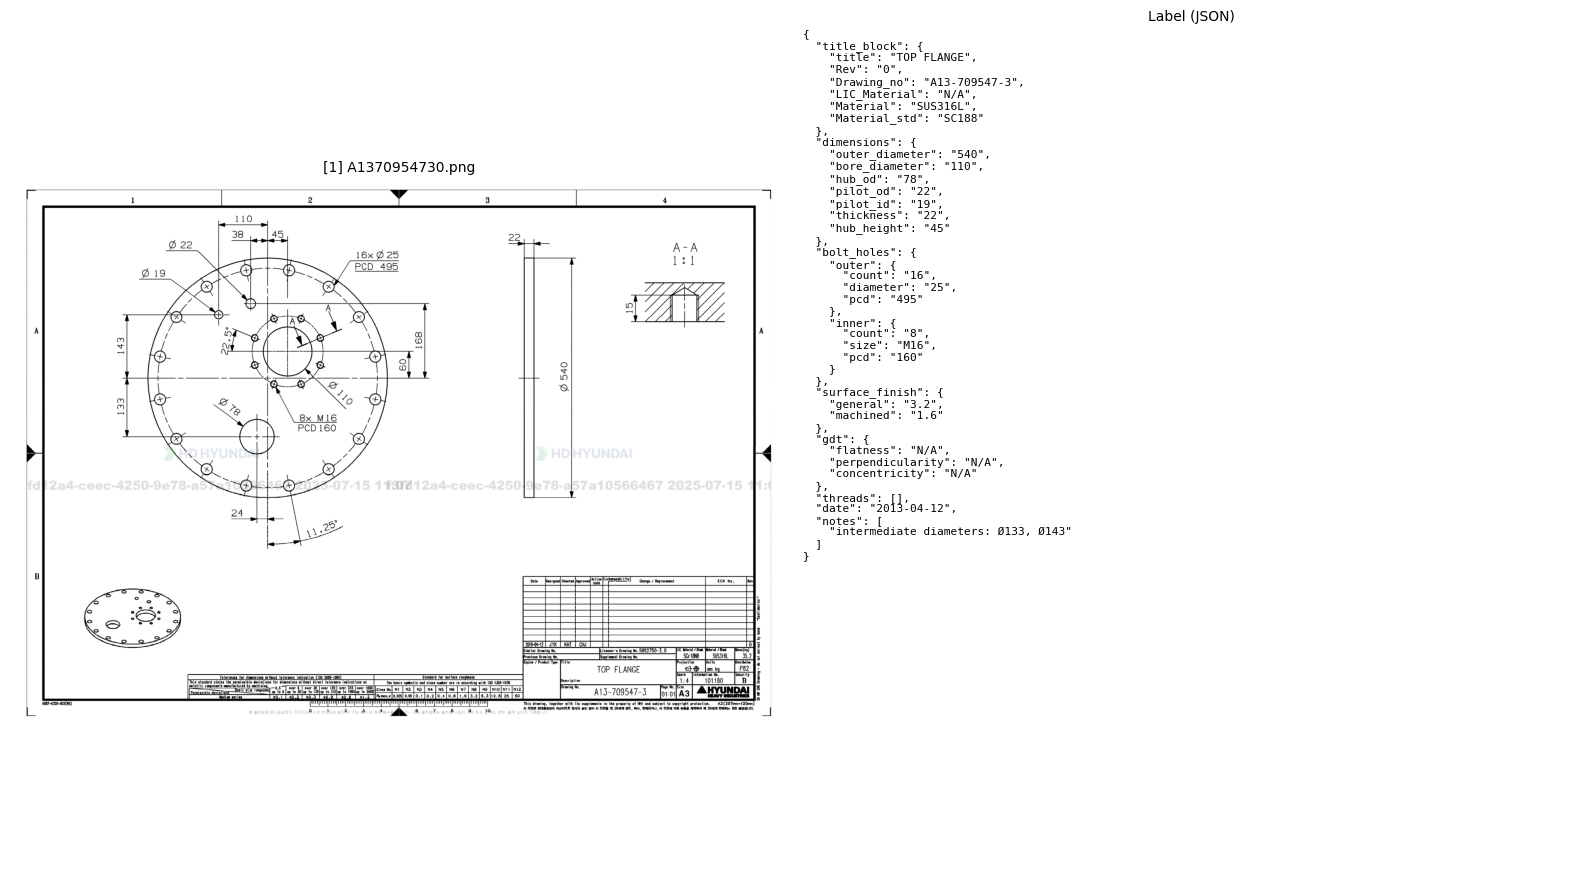

N/A fields: 4 (verify whether the drawing actually has these values):
  - /title_block/LIC_Material
  - /gdt/flatness
  - /gdt/perpendicularity
  - /gdt/concentricity


In [7]:
# ── 라벨 ↔ 이미지 대조 (검토용) ──────────────
# 도면 이미지와 해당 라벨 JSON을 나란히 띄워 사람이 눈으로 검토합니다.
# IDX만 바꿔가며 한 장씩 확인하세요 (0 ~ 49).
import json
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

DRAW_DIR = Path("data/drawings")
imgs = sorted(p for p in (DRAW_DIR / "images").glob("*")
              if p.suffix.lower() in {".png", ".jpg", ".jpeg"})

IDX = 1   # ← 검토할 이미지 번호 (0부터)

img_path = imgs[IDX]
lbl_path = DRAW_DIR / "labels" / (img_path.stem + ".json")
label = json.loads(lbl_path.read_text(encoding="utf-8"))

fig, axes = plt.subplots(1, 2, figsize=(16, 9))
axes[0].imshow(Image.open(img_path).convert("RGB"))
axes[0].axis("off")
axes[0].set_title(f"[{IDX}] {img_path.name}", fontsize=10)

axes[1].axis("off")
axes[1].set_title("Label (JSON)", fontsize=10)
axes[1].text(0.0, 1.0, json.dumps(label, indent=2, ensure_ascii=False),
             transform=axes[1].transAxes, fontsize=8,
             va="top", ha="left", fontfamily="monospace")
plt.tight_layout()
plt.show()

# N/A로 채워진 필드 = 도면에 실제 값이 있는지 우선 확인할 후보
def na_paths(obj, prefix=""):
    out = []
    if isinstance(obj, dict):
        for k, v in obj.items():
            out += na_paths(v, f"{prefix}/{k}")
    elif isinstance(obj, list):
        for i, v in enumerate(obj):
            out += na_paths(v, f"{prefix}[{i}]")
    elif obj == "N/A":
        out.append(prefix)
    return out

nas = na_paths(label)
print(f"N/A fields: {len(nas)} (verify whether the drawing actually has these values):")
for p in nas:
    print("  -", p)


> 🔹 **라벨 검수 게이트** — train/val 분리 *직전*, `data/drawings/validate_labels.py` 로 전체 라벨 JSON을 점검합니다(코어 키·bolt_holes 구조·미입력 빈값·카탈로그 키 난립·이미지 페어링). **ERROR가 1건이라도 있으면 `AssertionError` 로 멈춰** 아래 분할 셀이 실행되지 않습니다 — 잘못된 라벨이 학습 데이터로 흘러가는 것을 차단합니다. (WARN 은 표시만 하고 막지 않음; 엄격 모드는 `--strict` 인자 추가.)

In [8]:
# ── 라벨 검수 게이트 (train/val 분리 직전 자동 실행) ──────────────
# data/drawings/validate_labels.py 를 그대로 호출(단일 소스)해 라벨 스키마를 점검합니다.
# ERROR(코어 키 누락·구조 오류·미입력 등)가 있으면 AssertionError 로 멈춰
# 아래 분할 셀로 넘어가지 못하게 합니다 — 라벨 품질 = 모델 품질.
import subprocess, sys

_val = subprocess.run(
    [sys.executable, "data/drawings/validate_labels.py"],  # 스크립트가 __file__ 로 self-locate → cwd 무관
    capture_output=True, text=True,
)
print(_val.stdout, end="")
if _val.stderr:
    print(_val.stderr, end="")

assert _val.returncode == 0, (
    "라벨 검수 실패 — 위 [ERROR]/[PAIR] 항목을 고친 뒤 이 셀을 다시 실행하세요. (분할 중단)"
)
print("검수 통과 ✓ — 아래 train/val 분리 셀을 진행하세요.")


────────────────────────────────────────────────────────────
검수 대상: 50개 라벨 / 50개 이미지
페어 불일치: 0건
ERROR: 0건 (0개 파일) | WARN: 0건 (0개 파일)
결과: ✅ 통과
검수 통과 ✓ — 아래 train/val 분리 셀을 진행하세요.


> 🔹 **도면 train/val 분리** — 스키마 단순화(빈값·롱테일 키 제거) 후 데이터 정리

In [9]:
# ── 도면 데이터 train/val 분리 (+ 스키마 단순화) ─────────────────
import shutil, json, random
from pathlib import Path
from collections import Counter

SRC_DIR    = Path("data/drawings")            # 원본 이미지+JSON
OUT_DIR    = Path("data/processed_drawings")  # 정리 결과
VAL_RATIO  = 0.1
SEED       = CFG["training"]["seed"]

# ── 스키마 단순화 옵션 ──────────────────────────────────────────
# 데이터가 적어(~50장) 과적합이 큼 → 모델이 외워야 할 필드를 줄여 단순화합니다.
#   · N/A·빈 값 leaf 제거: "빈 칸/해당없음"을 학습하는 보일러플레이트를 없앰
#   · 롱테일 키 제거: 전 도면에서 거의 안 나오는(1회성) 키는 학습이 불가능 → 제거
SIMPLIFY_SCHEMA = False                      # 고정 스키마: 원본 라벨(N/A·전체 키) 그대로 복사
                                             # True 면 아래처럼 N/A·롱테일 키 제거(단순화)
DROP_VALUES     = {"", None, "N/A", "n/a"}   # 이 값을 가진 leaf 는 제거
MIN_KEY_FREQ    = 2                          # 전체 도면에서 이 횟수 미만 등장 키 제거 (1 = 끄기)

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".tiff", ".bmp"}


def prune_values(obj):
    """값이 DROP_VALUES 인 leaf 를 제거하고, 빈 dict/list 도 정리."""
    if isinstance(obj, dict):
        out = {}
        for k, v in obj.items():
            v2 = prune_values(v)
            if v2 not in (None, "", {}, []):
                out[k] = v2
        return out
    if isinstance(obj, list):
        items = [prune_values(v) for v in obj]
        return [v for v in items if v not in (None, "", {}, [])]
    return None if obj in DROP_VALUES else obj


def collect_key_counts(objs):
    """key 이름별 등장 횟수(전체 도면 기준)를 셉니다 — 롱테일 키 판별용."""
    cnt = Counter()
    def rec(o):
        if isinstance(o, dict):
            for k, v in o.items():
                cnt[k] += 1; rec(v)
        elif isinstance(o, list):
            for v in o:
                rec(v)
    for o in objs:
        rec(o)
    return cnt


def prune_keys(obj, drop):
    """drop 집합에 든 key 이름을 (어느 깊이에서든) 제거."""
    if isinstance(obj, dict):
        return {k: prune_keys(v, drop) for k, v in obj.items() if k not in drop}
    if isinstance(obj, list):
        return [prune_keys(v, drop) for v in obj]
    return obj


def count_leaves(o):
    if isinstance(o, dict):
        return sum(count_leaves(v) for v in o.values())
    if isinstance(o, list):
        return sum(count_leaves(v) for v in o)
    return 1


# 이미지-라벨 쌍 수집 (images/ + labels/ 구조)
pairs = []
for img in sorted(SRC_DIR.glob("images/*")):
    if img.suffix.lower() not in IMAGE_EXTS:
        continue
    label = SRC_DIR / "labels" / (img.stem + ".json")
    if label.exists():
        pairs.append((img, label))

if not pairs:
    print(f"이미지+JSON 쌍을 찾을 수 없습니다: {SRC_DIR}")
else:
    # ── 스키마 단순화 전처리: 라벨 dict 를 미리 변환해 둠 ──────────
    raw_labels = {lbl: json.loads(lbl.read_text(encoding="utf-8")) for _, lbl in pairs}
    if SIMPLIFY_SCHEMA:
        final_labels = {lbl: prune_values(obj) for lbl, obj in raw_labels.items()}
        drop_keys = set()
        if MIN_KEY_FREQ > 1:
            counts    = collect_key_counts(final_labels.values())
            drop_keys = {k for k, c in counts.items() if c < MIN_KEY_FREQ}
            final_labels = {lbl: prune_keys(obj, drop_keys) for lbl, obj in final_labels.items()}
        before = sum(count_leaves(o) for o in raw_labels.values())
        after  = sum(count_leaves(o) for o in final_labels.values())
        print(f"[스키마 단순화] leaf {before} → {after} (N/A·빈 값 제거)")
        print(f"               제거된 롱테일 키: {sorted(drop_keys) if drop_keys else '없음'}")
    else:
        final_labels = raw_labels

    random.seed(SEED)
    random.shuffle(pairs)
    n_val       = max(1, int(len(pairs) * VAL_RATIO))
    val_pairs   = pairs[:n_val]
    train_pairs = pairs[n_val:]

    # 재실행 시 중복 방지를 위해 기존 출력 폴더 초기화
    if OUT_DIR.exists():
        shutil.rmtree(OUT_DIR)

    for split_name, split_pairs in [("train", train_pairs), ("val", val_pairs)]:
        img_out = OUT_DIR / split_name / "images"
        lbl_out = OUT_DIR / split_name / "labels"
        img_out.mkdir(parents=True, exist_ok=True)
        lbl_out.mkdir(parents=True, exist_ok=True)
        for img_path, lbl_path in split_pairs:
            shutil.copy2(img_path, img_out / img_path.name)
            (lbl_out / lbl_path.name).write_text(
                json.dumps(final_labels[lbl_path], ensure_ascii=False, indent=2),
                encoding="utf-8")

    # CFG 로컬 경로 동기화 (CFG에 이미 설정되어 있지만 재확인)
    CFG["data"]["dataset_name"]    = None
    CFG["data"]["local_train_dir"] = str(OUT_DIR / "train")
    CFG["data"]["local_val_dir"]   = str(OUT_DIR / "val")
    print(f"완료: train {len(train_pairs)}개 / val {len(val_pairs)}개")
    print(f"출력: {OUT_DIR}")
    print(f"task_prompt = {CFG['data']['task_prompt']}  (CFG에 이미 설정됨)")

[스키마 단순화] leaf 1174 → 724 (N/A·빈 값 제거)
               제거된 롱테일 키: ['boss_diameter', 'boss_height', 'fit', 'flatness', 'gdt', 'hub_height', 'hub_od', 'inner_bore', 'pilot_id', 'slip_on_id', 'width']
완료: train 45개 / val 5개
출력: data/processed_drawings
task_prompt = <s_drawing>  (CFG에 이미 설정됨)


## Step 2 – 모델 & 프로세서 로드

- **DonutProcessor**: 이미지 전처리(resize/normalize) + 텍스트 토크나이저를 하나로 묶은 유틸리티
- **VisionEncoderDecoderModel**: 인코더(Swin-T) + 디코더(BART) 결합 모델

태스크 토큰(`<s_drawing>`)과 라벨의 모든 필드 토큰을 토크나이저에 추가한 뒤 임베딩 레이어를 확장합니다.

> 🔹 **모델·프로세서 빌드** — Donut 가중치 로드, 해상도/max_length 재설정

In [10]:
# ── Step 2: 모델 & 프로세서 빌드 ─────────────────────────────────
def build_model_and_processor(cfg):
    model_cfg  = cfg["model"]
    name       = model_cfg["pretrained_model_name"]
    image_size = model_cfg["image_size"]   # [height, width]
    max_length = model_cfg["max_length"]

    # HuggingFace Hub에서 사전학습된 가중치와 설정을 다운로드합니다.
    # 처음 실행 시 모델 파일이 캐시(~/.cache/huggingface)에 저장되므로
    # 이후 실행부터는 인터넷 연결 없이도 동작합니다.
    processor = DonutProcessor.from_pretrained(name, use_fast=False)
    model     = VisionEncoderDecoderModel.from_pretrained(name)
    # base(Donut/MBart)는 lm_head가 embed_tokens와 묶여(tied) 같은 텐서를 공유한다.
    # 이를 False로 두면 (1)config만 바뀔 뿐 실제 텐서는 계속 공유되고,
    # (2)저장 시 safetensors가 공유 텐서를 중복제거해 lm_head를 버려서,
    # (3)재로드 때 lm_head가 랜덤 초기화 → 출력이 깨진다. 반드시 True 유지.
    model.config.decoder.tie_word_embeddings = True
    model.config.tie_word_embeddings = True

    # ── 인코더 입력 해상도 재설정 ──────────────────────────────────
    # 사전학습 해상도와 다를 경우, 프로세서와 모델 config를 모두 변경해야
    # 실제 forward pass에서 이미지 크기가 일치합니다.
    # 프로세서: 이미지를 리사이즈할 때 사용할 목표 크기
    processor.image_processor.size = {"height": image_size[0], "width": image_size[1]}
    # do_align_long_axis=False: 세로 이미지를 회전하지 않고 그대로 사용
    processor.image_processor.do_align_long_axis = False
    # 모델 config: 인코더가 실제로 처리할 해상도와 디코더 최대 길이 반영
    model.config.encoder.image_size = image_size
    model.config.decoder.max_length = max_length

    # ── 태스크 토큰 + 필드 토큰을 토크나이저에 추가 ───────────────
    # Donut은 특수 토큰으로 태스크와 JSON 필드를 구분합니다.
    #  (1) task_prompt : 디코더 시작 토큰 (예: <s_title_block>)
    #  (2) 필드 토큰   : 라벨 JSON의 모든 키 → <s_{key}> / </s_{key}> 와 <sep/>
    # ★ 필드 토큰을 special token으로 등록하지 않으면 필드명이 subword로 쪼개져
    #   학습이 거의 안 됩니다(깨진 출력의 핵심 원인). 반드시 함께 추가하세요.
    task_prompt = cfg["data"]["task_prompt"]

    def _collect_keys(obj, ks):
        if isinstance(obj, dict):
            for k, v in obj.items():
                ks.add(k); _collect_keys(v, ks)
        elif isinstance(obj, list):
            for v in obj:
                _collect_keys(v, ks)

    # ★ train + val 라벨을 모두 스캔해 키를 수집합니다.
    #   (val에만 등장하는 희귀 키 — 예: 선택 치수 카탈로그의 일회성 키 — 가
    #    미등록 토큰으로 새어 학습/평가가 깨지는 것을 방지)
    keys = set()
    for split in ("local_train_dir", "local_val_dir"):
        label_dir = Path(cfg["data"][split]) / "labels"
        for f in sorted(label_dir.glob("*.json")):
            _collect_keys(json.load(open(f, encoding="utf-8")), keys)
    field_tokens = []
    for k in sorted(keys):
        field_tokens += [f"<s_{k}>", f"</s_{k}>"]

    special_tokens = list(dict.fromkeys([task_prompt, "<sep/>"] + field_tokens))
    num_added = processor.tokenizer.add_special_tokens(
        {"additional_special_tokens": special_tokens}
    )
    if num_added:
        # 토크나이저 크기가 바뀌었으므로 모델의 임베딩 레이어도 함께 확장
        model.decoder.resize_token_embeddings(len(processor.tokenizer))
    print(f"special token 추가: {num_added}개 (task 1 + 필드 키 {len(keys)}종, train+val)")

    # ── 디코더 시작/패딩 토큰 연결 ────────────────────────────────
    # pad_token_id : 배치 내 길이를 맞추기 위한 패딩 토큰 ID
    # decoder_start_token_id : 디코더가 생성을 시작할 때 첫 입력으로 사용하는 토큰
    #   → task_prompt("<s_drawing>")가 첫 토큰이 되어 태스크를 인식합니다
    model.config.pad_token_id           = processor.tokenizer.pad_token_id
    model.config.decoder_start_token_id = processor.tokenizer.convert_tokens_to_ids(
        [task_prompt]
    )[0]

    return model, processor


model, processor = build_model_and_processor(CFG)

# GPU가 있으면 GPU로, 없으면 CPU로 모델을 이동
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = model.to(device)

enc_params = sum(p.numel() for p in model.encoder.parameters()) / 1e6
dec_params = sum(p.numel() for p in model.decoder.parameters()) / 1e6
print(f"디바이스       : {device}")
print(f"인코더 파라미터: {enc_params:.1f}M  (Swin Transformer — 이미지 특징 추출)")
print(f"디코더 파라미터: {dec_params:.1f}M  (BART — 토큰 시퀀스 생성)")
print(f"Decoder start token: {processor.tokenizer.convert_ids_to_tokens([model.config.decoder_start_token_id])}")


[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.
Loading weights: 100%|██████████| 484/484 [00:00<00:00, 63476.54it/s]
[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


special token 추가: 60개 (task 1 + 필드 키 29종, train+val)
디바이스       : cuda
인코더 파라미터: 74.2M  (Swin Transformer — 이미지 특징 추출)
디코더 파라미터: 127.7M  (BART — 토큰 시퀀스 생성)
Decoder start token: ['<s_drawing>']


## Step 3 – 데이터셋 구성 & 시각화

### DonutDataset 동작 원리

| 입력 | 처리 | 출력 |
|------|------|------|
| PIL Image | DonutProcessor → pixel_values | `(C, H, W)` Tensor |
| JSON ground truth | Tokenizer → teacher-forcing label | `(max_length,)` Token IDs |

**패딩 토큰 → -100**: CrossEntropyLoss는 `-100`으로 표시된 위치를 자동으로 무시합니다 (패딩 위치에서 loss 계산 안 함).

### 사용 가능한 데이터셋

#### 기본 제공 (HuggingFace 자동 다운로드)

| 데이터셋 | 태스크 | 크기 | HuggingFace ID |
|---------|--------|------|----------------|
| **CORD-v2** | 영수증 정보 추출 | train 800 / val 100 / test 100 | `naver-clova-ix/cord-v2` |
| **DocVQA** | 문서 질의응답 | train 10,194 / val 1,286 | `naver-clova-ix/docvqa_en` |
| **RVL-CDIP** | 문서 분류 (16종) | train 320,000 / val 40,000 | `rvl_cdip` |

데이터셋 페이지: https://huggingface.co/datasets/naver-clova-ix/cord-v2

`CFG`에서 ID만 바꾸면 자동으로 다운로드됩니다:
```python
# CORD-v2 (기본값 — 영수증)
CFG["data"]["dataset_name"] = "naver-clova-ix/cord-v2"
CFG["data"]["task_prompt"]  = "<s_cord-v2>"

# DocVQA (문서 질의응답)
CFG["data"]["dataset_name"] = "naver-clova-ix/docvqa_en"
CFG["data"]["task_prompt"]  = "<s_docvqa>"

# 커스텀 로컬 데이터셋
CFG["data"]["dataset_name"]    = None
CFG["data"]["local_train_dir"] = "data/processed_drawings/train"
CFG["data"]["local_val_dir"]   = "data/processed_drawings/val"
CFG["data"]["task_prompt"]     = "<s_drawing>"   # 이 노트북의 도면 설정
```

> 🔹 **DonutDataset 정의** — json2token 변환 및 커스텀 Dataset 클래스

In [11]:
# ── Step 3a: DonutDataset 정의 ────────────────────────────────────

def json2token(obj, sort_keys=True):
    '''dict/list → Donut 토큰 시퀀스 변환.

    Donut의 정답은 JSON을 XML 스타일 토큰으로 표현합니다.
    예) {"total": "12500"} → <s_total>12500</s_total>
        {"items": [{"nm": "A"}]} → <s_items><s_nm>A</s_nm></s_items>

    sort_keys=True : 키를 역순 정렬하여 항상 동일한 순서를 보장합니다.
    '''
    if isinstance(obj, dict):
        output = ""
        keys = sorted(obj.keys(), reverse=True) if sort_keys else obj.keys()
        for k in keys:
            # 재귀 호출로 중첩 dict/list도 처리
            output += f"<s_{k}>" + json2token(obj[k], sort_keys) + f"</s_{k}>"
        return output
    elif isinstance(obj, list):
        # 리스트 항목은 <sep/> 토큰으로 구분
        return "<sep/>".join([json2token(v, sort_keys) for v in obj])
    else:
        return str(obj)


# ── (논문 Numerical VLM) Unicode code-point 인코딩: 값의 기호 → "U+XXXX" ASCII ──
#   기호(Ø,⊥,±,° …)를 코드포인트 ASCII 로 표현 → 토크나이저 글리프 OOV/NFKC 제거, 출력 안정.
import re as _re_u
def _keep_native(c):   # CJK/한글/가나/전각 — 다국어 토크나이저가 처리하므로 인코딩하지 않음
    o = ord(c)
    return (0xAC00 <= o <= 0xD7A3) or (0x1100 <= o <= 0x11FF) or (0x3130 <= o <= 0x318F) \
        or (0x4E00 <= o <= 0x9FFF) or (0x3040 <= o <= 0x30FF) or (0xFF00 <= o <= 0xFFEF)
def encode_symbols(s):
    # 공학 기호(Ø,⊥,±,°,×,√ …)만 "U+XXXX" 로. ASCII·CJK/한글은 그대로(토크나이저가 처리).
    return "".join(c if (ord(c) <= 127 or _keep_native(c)) else f" U+{ord(c):04X} " for c in str(s))
def decode_symbols(s):
    return _re_u.sub(r"\s*U\+([0-9A-Fa-f]{4,6})\s*", lambda m: chr(int(m.group(1), 16)), str(s))
def _walk(o, fn):
    if isinstance(o, dict): return {k: _walk(v, fn) for k, v in o.items()}
    if isinstance(o, list): return [_walk(v, fn) for v in o]
    return fn(str(o))
def encode_tree(o): return _walk(o, encode_symbols)   # dict/list 모든 leaf 인코딩
def decode_tree(o): return _walk(o, decode_symbols)


class DonutDataset(Dataset):
    '''HuggingFace 데이터셋 split 또는 로컬 디렉터리를 Donut 학습용으로 변환.

    로컬 디렉터리 레이아웃:
        <root>/
            images/   *.png / *.jpg
            labels/   *.json   (이미지와 동일한 파일명 stem)
    '''

    def __init__(self, dataset_or_root, processor, max_length: int, task_prompt: str):
        self.processor   = processor
        self.max_length  = max_length
        self.task_prompt = task_prompt

        # 입력 타입에 따라 HuggingFace 모드 / 로컬 모드를 자동 선택
        if isinstance(dataset_or_root, (str, Path)):
            self.samples = self._load_local(Path(dataset_or_root))
            self.mode    = "local"
        else:
            self.hf_dataset = dataset_or_root
            self.mode       = "hf"

    def _load_local(self, root: Path):
        # images/와 labels/ 폴더에서 같은 파일명을 가진 쌍을 찾아 리스트로 반환
        image_exts = {".png", ".jpg", ".jpeg", ".tiff", ".bmp"}
        samples = []
        for img_path in sorted((root / "images").glob("*")):
            if img_path.suffix.lower() not in image_exts:
                continue
            label_path = root / "labels" / (img_path.stem + ".json")
            if label_path.exists():
                samples.append((img_path, label_path))
        return samples

    def __len__(self):
        return len(self.hf_dataset) if self.mode == "hf" else len(self.samples)

    def __getitem__(self, idx):
        # ── 이미지와 정답 시퀀스 준비 ────────────────────────────
        if self.mode == "hf":
            sample = self.hf_dataset[idx]
            image  = sample["image"].convert("RGB")
            gt     = json.loads(sample["ground_truth"])
            if "gt_parse" in gt:
                # gt_parse는 이미 dict → json2token()으로 토큰 시퀀스 변환
                # 예: <s_cord-v2><s_total>12500</s_total>...</s_cord-v2>EOS
                target_seq = (
                    self.task_prompt
                    + json2token(encode_tree(gt["gt_parse"]))   # 기호 Unicode 인코딩
                    + self.processor.tokenizer.eos_token  # 문장 끝 토큰
                )
            else:
                target_seq = self.task_prompt + self.processor.tokenizer.eos_token
        else:
            img_path, label_path = self.samples[idx]
            image = Image.open(img_path).convert("RGB")
            with open(label_path) as f:
                gt = json.load(f)
            target_seq = (
                self.task_prompt
                + json2token(encode_tree(gt))   # 기호 Unicode 인코딩
                + self.processor.tokenizer.eos_token
            )

        # ── 이미지 → pixel_values ────────────────────────────────
        # DonutProcessor가 이미지를 지정 해상도로 리사이즈하고
        # 픽셀 값을 [-1, 1] 범위로 정규화합니다.
        # squeeze(0): 배치 차원 제거 → (1, C, H, W) → (C, H, W)
        pixel_values = self.processor(
            image, return_tensors="pt"
        ).pixel_values.squeeze(0)

        # ── 정답 텍스트 → label token IDs ────────────────────────
        # Teacher Forcing 학습을 위해 정답 시퀀스를 토큰 ID로 변환합니다.
        # padding="max_length" : 짧은 시퀀스를 max_length까지 패딩 토큰으로 채움
        # truncation=True      : max_length를 초과하면 잘라냄
        labels = self.processor.tokenizer(
            target_seq,
            add_special_tokens=False,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        ).input_ids.squeeze(0)

        # 패딩 위치를 -100으로 마스킹
        # CrossEntropyLoss는 target=-100인 위치를 자동으로 무시합니다.
        # 즉, 의미 없는 패딩 토큰에서는 loss가 계산되지 않습니다.
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {
            "pixel_values":    pixel_values,   # 모델 입력 이미지
            "labels":          labels,          # Teacher Forcing 정답 레이블
            "target_sequence": target_seq,      # 평가 시 문자열 비교용
        }

print("DonutDataset 클래스 정의 완료 ✓")


DonutDataset 클래스 정의 완료 ✓


> 🔹 **데이터셋 로드** — 로컬 디렉터리에서 train/val 데이터셋 구성

In [12]:
# ── Step 3b: 데이터셋 로드 ────────────────────────────────────────
# CFG 설정에 따라 HuggingFace 또는 로컬 디렉터리에서 데이터를 로드합니다.
# dataset_name이 지정되면 인터넷에서 자동 다운로드하고,
# None이면 local_train_dir / local_val_dir 경로를 사용합니다.
def build_datasets(cfg, processor):
    data_cfg   = cfg["data"]
    max_length = cfg["model"]["max_length"]
    prompt     = data_cfg["task_prompt"]

    if data_cfg.get("dataset_name"):          # HuggingFace 데이터셋
        from datasets import load_dataset
        # load_dataset은 처음 실행 시 다운로드 후 로컬에 캐시합니다
        raw      = load_dataset(data_cfg["dataset_name"])
        train_ds = DonutDataset(raw[data_cfg["train_split"]], processor, max_length, prompt)
        val_ds   = DonutDataset(raw[data_cfg["val_split"]],   processor, max_length, prompt)
    else:                                      # 로컬 디렉터리
        train_ds = DonutDataset(data_cfg["local_train_dir"], processor, max_length, prompt)
        val_ds   = DonutDataset(data_cfg["local_val_dir"],   processor, max_length, prompt)

    return train_ds, val_ds


train_ds, val_ds = build_datasets(CFG, processor)
print(f"Train 샘플 수: {len(train_ds):,}")
print(f"Val   샘플 수: {len(val_ds):,}")


Train 샘플 수: 45
Val   샘플 수: 5


> 🔹 **샘플 시각화** — 이미지와 정답 토큰을 핵심 필드 우선 순서로 미리보기

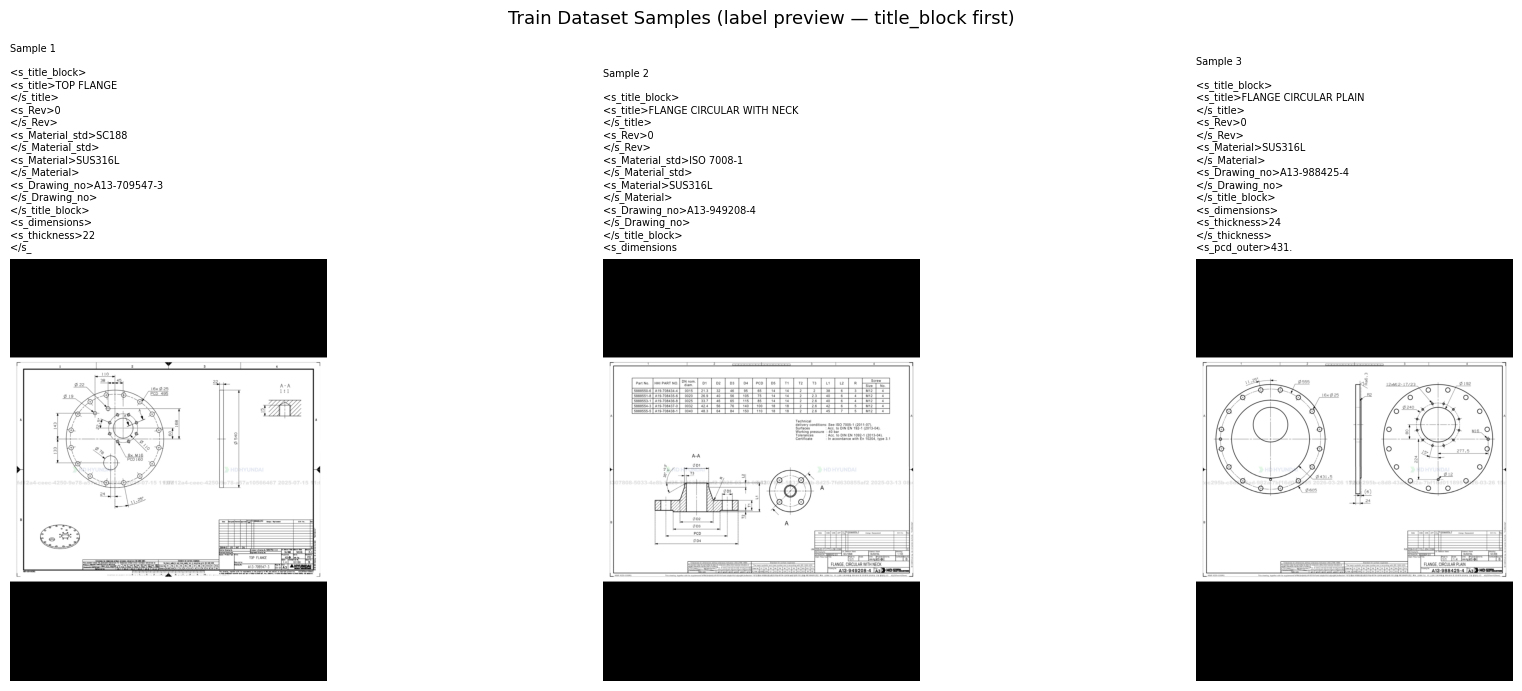


Sample 1 - valid tokens: 109 / 768
  (659 tokens are padding - excluded from loss)


In [13]:
# ── Step 3c: 샘플 시각화 ──────────────────────────────────────────
# 학습 데이터가 올바르게 로드됐는지 눈으로 확인합니다.
# 라벨(정답)을 핵심 필드(title_block) 우선 순서로, 더 길게 표시합니다.
# (target_sequence는 json2token이 키를 역순 정렬해 샘플마다 앞 필드가 달라지므로,
#  미리보기는 아래 PREVIEW_ORDER로 다시 정렬해 일관되게 보여줍니다.)
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

PREVIEW_ORDER = ["title_block", "dimensions", "bolt_holes",
                 "surface_finish", "gdt", "threads", "date"]
PREVIEW_CHARS = 220   # 표시할 토큰 문자 수 (이전 80 → 220)

def preview_seq(label: dict) -> str:
    # PREVIEW_ORDER에 있는 키를 먼저, 그 외 키는 뒤에 붙여 토큰화
    keys = [k for k in PREVIEW_ORDER if k in label] + \
           [k for k in label if k not in PREVIEW_ORDER]
    s = "".join(f"<s_{k}>" + json2token(label[k]) + f"</s_{k}>" for k in keys)
    return s[:PREVIEW_CHARS]

for idx, ax in enumerate(axes):
    i = idx + 1  # 1,2,3번째 샘플을 출력
    sample = train_ds[i]

    # pixel_values는 [-1, 1]로 정규화되어 있으므로 [0, 1]로 되돌려 표시
    img_tensor = sample["pixel_values"]
    img_np     = (img_tensor.permute(1, 2, 0).numpy() + 1) / 2  # [-1,1] → [0,1]
    img_np     = img_np.clip(0, 1)
    ax.imshow(img_np)
    ax.axis("off")

    # 로컬 모드: 라벨 dict를 파일에서 직접 읽어 핵심 필드 우선으로 미리보기 구성
    if getattr(train_ds, "mode", "local") == "local":
        label    = json.load(open(train_ds.samples[i][1], encoding="utf-8"))
        gt_short = preview_seq(label)
    else:
        gt_short = sample["target_sequence"][:PREVIEW_CHARS]
    # "<" 앞에 줄바꿈을 넣어 토큰 구조를 읽기 쉽게
    gt_short = gt_short.replace("<", "\n<")
    ax.set_title(f"Sample {i}\n{gt_short}", fontsize=7, loc="left")

plt.suptitle("Train Dataset Samples (label preview — title_block first)", fontsize=13)
plt.tight_layout()
plt.show()

# 유효 토큰 수 확인: -100이 아닌 위치 = 실제 정답 토큰 수
# max_length 중 실제 정보가 몇 토큰인지 파악할 수 있습니다
valid_tokens = (train_ds[1]["labels"] != -100).sum().item()
print(f"\nSample 1 - valid tokens: {valid_tokens} / {CFG['model']['max_length']}")
print(f"  ({CFG['model']['max_length'] - valid_tokens} tokens are padding - excluded from loss)")


## Step 4 – 학습 (Training)

`Seq2SeqTrainer`를 사용합니다.

| 주요 옵션 | 설명 |
|-----------|------|
| `predict_with_generate=True` | 평가 시 모델이 실제로 토큰을 생성하여 metric 계산 |
| `bf16=True` | Mixed Precision(bf16) — VRAM 절감, Donut에서 fp16보다 안정 |
| `gradient_accumulation_steps` | 실효 배치를 크게 유지하면서 VRAM 절감 |
| `load_best_model_at_end=True` | 학습 종료 후 val loss 최저 체크포인트를 자동 복원 |

> 🔹 **학습 실행** — Seq2SeqTrainer로 파인튜닝(+조기 종료) 및 체크포인트 저장

In [14]:
# ── Step 4: 학습 실행 ─────────────────────────────────────────────
# Seq2SeqTrainer가 다음을 자동으로 처리합니다:
#   - 매 스텝: forward → loss 계산 → backward → 가중치 업데이트
#   - 매 eval_steps: 검증셋으로 eval_loss 측정
#   - 매 save_steps: 체크포인트 저장
#   - 학습 완료 후: eval_loss 최소 체크포인트 자동 복원
if CFG["wandb"]["enabled"]:
    import wandb
    wandb.init(
        project=CFG["wandb"]["project"],
        name=CFG["wandb"]["run_name"],
        config=CFG,
    )

from transformers import EarlyStoppingCallback   # 조기 종료 콜백

tcfg = CFG["training"]

training_args = Seq2SeqTrainingArguments(
    output_dir                  = tcfg["output_dir"],
    num_train_epochs            = tcfg["num_epochs"],
    per_device_train_batch_size = tcfg["batch_size"],
    per_device_eval_batch_size  = tcfg["batch_size"],
    gradient_accumulation_steps = tcfg["gradient_accumulation_steps"],
    learning_rate               = tcfg["learning_rate"],
    warmup_steps                = tcfg["warmup_steps"],   # 초반 lr 웜업 구간
    weight_decay                = tcfg["weight_decay"],   # 과적합 방지 정규화
    bf16                        = tcfg.get("bf16", True),  # bf16 혼합정밀도 (Donut 안정적)
    fp16                        = tcfg.get("fp16", False),
    save_steps                  = tcfg["save_steps"],
    eval_steps                  = tcfg["eval_steps"],
    logging_steps               = tcfg["logging_steps"],
    save_total_limit            = 3,          # 가장 최신 체크포인트 3개만 보관
    eval_strategy               = "steps",    # transformers ≥4.45 변경된 파라미터명
    predict_with_generate       = True,       # 평가 시 실제로 토큰을 생성해서 비교
    dataloader_num_workers      = tcfg["dataloader_num_workers"],
    report_to                   = ["wandb"] if CFG["wandb"]["enabled"] else ["none"],
    load_best_model_at_end      = True,       # 학습 후 eval_loss 최저 모델 자동 복원
    metric_for_best_model       = "eval_loss",
    greater_is_better           = False,      # loss는 낮을수록 좋음
)

# eval_loss 가 좋아지지 않으면 학습을 일찍 멈춥니다 (load_best_model_at_end 로 best 복원).
callbacks = []
patience  = tcfg.get("early_stopping_patience")
if patience:
    callbacks.append(EarlyStoppingCallback(early_stopping_patience=patience))

trainer = Seq2SeqTrainer(
    model         = model,
    args          = training_args,
    train_dataset = train_ds,
    eval_dataset  = val_ds,
    callbacks     = callbacks,
)

# 실효 배치 크기 = batch_size × gradient_accumulation_steps
print(f"실효 배치 크기: {tcfg['batch_size']} × {tcfg['gradient_accumulation_steps']} = "
      f"{tcfg['batch_size'] * tcfg['gradient_accumulation_steps']}")
print(f"저장 경로    : {tcfg['output_dir']}")
print("\n학습 시작... (loss가 지속적으로 감소하는지 확인하세요)")
trainer.train()

# 최종 모델과 프로세서를 함께 저장합니다.
# 추론 시 같은 경로에서 둘 다 로드해야 합니다.
final_dir = os.path.join(tcfg["output_dir"], "final")
trainer.save_model(final_dir)
processor.save_pretrained(final_dir)
print(f"\n학습 완료! 모델 저장됨 → {final_dir}")


실효 배치 크기: 2 × 2 = 4
저장 경로    : checkpoints_drawings

학습 시작... (loss가 지속적으로 감소하는지 확인하세요)


Step,Training Loss,Validation Loss
50,13.961121,6.568165
100,9.499763,4.474121
150,4.261880,2.112202
200,2.963641,1.656487
250,2.288992,1.259631
300,1.563997,0.993203
350,1.156959,0.817112
400,0.876115,0.658965
450,0.679536,0.652277
500,0.523558,0.536969


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.15it/s]
[transformers] There were missing keys in the checkpoint model loaded: ['decoder.lm_head.weight'].
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.23it/s]


학습 완료! 모델 저장됨 → checkpoints_drawings/final


## 학습 곡선 — 과적합 점검 (train vs val loss)

학습이 끝난 직후 실행합니다. **train_loss는 계속 내려가는데 val_loss가 정체/상승**하면
과적합입니다 — 이 경우 `EarlyStoppingCallback`이 best 지점에서 학습을 멈춥니다.

> 🔹 **학습 곡선** — train_loss vs eval_loss 비교로 과적합 점검

Saved loss curve -> /home/jhkim/donut_vml/output/loss_curve.png


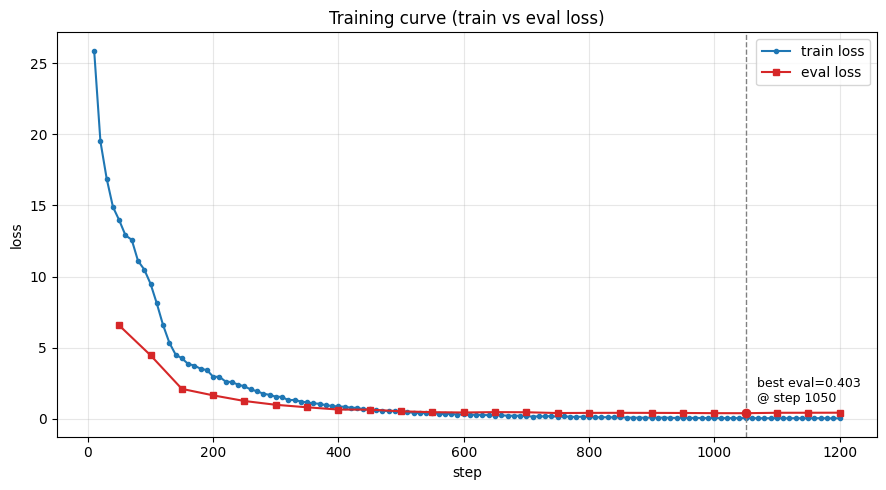

final train loss : 0.045
best  val  loss : 0.403 @ step 1050
final val  loss : 0.438
=> Overfitting likely: train << val (gap 0.39), val rose after best, best is before the end.


In [21]:
# ── 학습 곡선: train_loss vs eval_loss (과적합 점검) ──────────────
# 학습 직후 실행하세요. train은 계속 내려가는데 eval이 정체/상승하면 과적합 신호입니다.
# trainer가 메모리에 있으면 그 로그를, 없으면(커널 재시작) 최신 체크포인트의 로그를 사용합니다.
import os, glob, json
from pathlib import Path
import matplotlib.pyplot as plt


def load_log_history():
    """trainer.state.log_history 우선, 없으면 최신 checkpoint-*/trainer_state.json."""
    if "trainer" in globals() and getattr(trainer, "state", None) is not None:
        return trainer.state.log_history
    out = CFG["training"]["output_dir"] if "CFG" in globals() else "checkpoints_drawings"
    ckpts = sorted(glob.glob(os.path.join(out, "checkpoint-*")),
                   key=lambda p: int(p.split("-")[-1]))
    if not ckpts:
        raise FileNotFoundError(f"No log history (trainer 없음, {out}에 checkpoint도 없음).")
    state = json.load(open(os.path.join(ckpts[-1], "trainer_state.json"), encoding="utf-8"))
    return state.get("log_history", [])


log   = load_log_history()
train = [(e["step"], e["loss"])      for e in log if "loss" in e and "eval_loss" not in e]
evals = [(e["step"], e["eval_loss"]) for e in log if "eval_loss" in e]

fig, ax = plt.subplots(figsize=(9, 5))
if train:
    ax.plot(*zip(*train), "o-", color="tab:blue", markersize=3, label="train loss")
if evals:
    ax.plot(*zip(*evals), "s-", color="tab:red", markersize=4, label="eval loss")
    best_step, best_eval = min(evals, key=lambda x: x[1])
    ax.axvline(best_step, ls="--", color="gray", lw=1)
    ax.scatter([best_step], [best_eval], color="tab:red", zorder=5)
    ax.annotate(f"best eval={best_eval:.3f}\n@ step {best_step}", (best_step, best_eval),
                textcoords="offset points", xytext=(8, 8), fontsize=9)
ax.set_xlabel("step")
ax.set_ylabel("loss")
ax.set_title("Training curve (train vs eval loss)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

OUT = Path("output") / "loss_curve.png"
OUT.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT, dpi=150)
print(f"Saved loss curve -> {OUT.resolve()}")
plt.show()

# ── 과적합 간단 진단 ─────────────────────────────────────────────
if train and evals:
    final_train          = train[-1][1]
    best_step, best_eval = min(evals, key=lambda x: x[1])
    final_eval           = evals[-1][1]
    last_step            = evals[-1][0]
    print(f"final train loss : {final_train:.3f}")
    print(f"best  val  loss : {best_eval:.3f} @ step {best_step}")
    print(f"final val  loss : {final_eval:.3f}")
    gap   = final_eval - final_train          # train≪eval 이면 일반화 실패
    rose  = final_eval > best_eval + 1e-3     # best 이후 eval 상승
    early = best_step < last_step             # eval 최저가 끝보다 앞
    if gap > 0.2 and (rose or early):
        print(f"=> Overfitting likely: train << val (gap {gap:.2f})"
              f"{', val rose after best' if rose else ''}"
              f"{', best is before the end' if early else ''}.")
    else:
        print(f"=> Weak overfitting signal (gap {gap:.2f}).")

## Step 5 – 평가 (Evaluation)

**Leaf-Match Score**: 예측 JSON과 정답 JSON의 모든 리프(leaf) 값을 비교하여 일치율을 계산합니다.  
(완전한 TED 구현을 원하면 `zss` 패키지를 사용하세요)

> 🔹 **평가 유틸리티** — token2json 역변환(리스트 <sep/> 복원 포함) 함수 정의

In [22]:
# ── Step 5a: 평가 유틸리티 ────────────────────────────────────────

def token2json(tokens: str) -> dict | str:
    '''모델이 생성한 토큰 시퀀스를 Python dict로 역변환.

    json2token()의 반대 과정입니다.
    예) "<s_total>12500</s_total>"            → {"total": "12500"}
        "<s_threads>M16<sep/>M20</s_threads>" → {"threads": ["M16", "M20"]}

    정규표현식으로 <s_key>...</s_key> 패턴을 찾아 재귀적으로 파싱합니다.
    값 안에 <sep/>가 있으면 리스트로 복원합니다 (json2token이 리스트를 <sep/>로 잇기 때문).
    ※ 단, 원소가 1개인 리스트는 <sep/>가 없어 문자열로 복원됩니다 — 토큰만으로는
      "M16"과 ["M16"]을 구분할 수 없는 인코딩의 본질적 한계입니다.
    '''
    output = {}
    while tokens:
        # 여는 태그 <s_key> 탐색
        start = re.search(r"<s_(.+?)>", tokens)
        if not start:
            break
        key     = start.group(1)
        end_pat = f"</s_{key}>"
        end_pos = tokens.find(end_pat, start.end())
        if end_pos == -1:
            break
        value = tokens[start.end():end_pos]
        if "<sep/>" in value:
            # 리스트: <sep/>로 분리 → 각 항목은 중첩 태그면 재귀 파싱, 아니면 문자열
            output[key] = [token2json(v) if "<s_" in v else v.strip()
                           for v in value.split("<sep/>")]
        elif "<s_" in value:
            # 값 안에 중첩 태그가 있으면 재귀 호출로 파싱
            output[key] = token2json(value)
        else:
            output[key] = value.strip()
        tokens = tokens[end_pos + len(end_pat):]
    return output if output else tokens.strip()


def compute_leaf_match(pred: dict, gt: dict) -> float:
    '''예측 JSON과 정답 JSON의 최말단(leaf) 값 일치율을 계산합니다 (0~1).

    중첩 구조를 평탄화(flatten)한 뒤 경로별로 값을 비교합니다.
    예) {"menu": {"nm": "Burger"}} → {"/menu/nm": "Burger"}
    전체 정답 leaf 중 예측이 맞춘 비율을 반환합니다.
    '''
    def flatten(d, prefix=""):
        items = {}
        if isinstance(d, dict):
            for k, v in d.items():
                items.update(flatten(v, f"{prefix}/{k}"))
        elif isinstance(d, list):
            for i, v in enumerate(d):
                items.update(flatten(v, f"{prefix}[{i}]"))
        else:
            items[prefix] = str(d)
        return items

    pred_flat = flatten(pred)
    gt_flat   = flatten(gt)
    if not gt_flat:
        return 1.0 if not pred_flat else 0.0
    matches = sum(pred_flat.get(k) == v for k, v in gt_flat.items())
    return matches / len(gt_flat)  # 일치한 leaf 수 / 전체 정답 leaf 수

print("평가 유틸리티 정의 완료 ✓")


평가 유틸리티 정의 완료 ✓


> 🔹 **검증셋 전체 평가** — 체크포인트 로드 후 Leaf-Match Score 계산

In [23]:
# ── Step 5b: Validation set 전체 평가 ────────────────────────────
# ※ 학습이 완료된 뒤 실행하세요.
# 저장된 체크포인트를 로드하고 검증 데이터 전체에 추론 → Leaf-Match Score 계산.

CHECKPOINT     = os.path.join(CFG["training"]["output_dir"], "final")
MAX_NEW_TOKENS = CFG["model"]["max_length"]   # 학습 max_length(768)와 동일하게
EVAL_BATCH     = 1

# 저장된 체크포인트가 있으면 로드, 없으면 현재 메모리의 model 사용
if os.path.isdir(CHECKPOINT):
    eval_processor = DonutProcessor.from_pretrained(CHECKPOINT, use_fast=False)
    eval_model     = VisionEncoderDecoderModel.from_pretrained(CHECKPOINT).to(device)
else:
    print(f"체크포인트 없음: {CHECKPOINT} — 현재 model 사용")
    eval_model, eval_processor = model, processor

eval_model.eval()

task_prompt = CFG["data"]["task_prompt"]
decoder_input_ids = eval_processor.tokenizer(
    task_prompt, add_special_tokens=False, return_tensors="pt"
).input_ids.to(device)

def _clean(seq: str) -> str:
    # 특수 토큰(BOS/EOS/PAD)과 task 토큰 제거 → token2json이 본문만 파싱하도록.
    # (task 토큰을 안 떼면 닫힘 태그 없는 키로 오인해 파싱 실패 → 점수가 0이 됨)
    for t in (eval_processor.tokenizer.eos_token, eval_processor.tokenizer.pad_token,
              eval_processor.tokenizer.bos_token, task_prompt):
        if t:
            seq = seq.replace(t, "")
    return seq.strip()

val_loader = DataLoader(val_ds, batch_size=EVAL_BATCH, shuffle=False, num_workers=2)

scores = []
with torch.inference_mode():
    for batch in tqdm(val_loader, desc="Evaluating"):
        pixel_values = batch["pixel_values"].to(device)
        outputs = eval_model.generate(
            pixel_values,
            decoder_input_ids = decoder_input_ids.expand(pixel_values.size(0), -1),
            max_new_tokens    = MAX_NEW_TOKENS,
            pad_token_id      = eval_processor.tokenizer.pad_token_id,
            eos_token_id      = eval_processor.tokenizer.eos_token_id,
            use_cache         = True,
        )
        for i, seq in enumerate(outputs):
            pred_str = _clean(eval_processor.batch_decode([seq], skip_special_tokens=False)[0])
            gt_str   = _clean(batch["target_sequence"][i])
            pred_json, gt_json = token2json(pred_str), token2json(gt_str)
            if isinstance(pred_json, dict) and isinstance(gt_json, dict):
                scores.append(compute_leaf_match(pred_json, gt_json))
            else:
                scores.append(1.0 if pred_str == gt_str else 0.0)

mean_score = sum(scores) / len(scores) if scores else 0.0
print(f"\n평가 완료 — {len(scores)} 샘플")
print(f"Leaf-Match Score: {mean_score:.4f} ({mean_score*100:.2f}%)")
print("  (1.0 = 모든 필드 완벽 일치 / 0.0 = 전혀 불일치)")


Evaluating: 100%|██████████| 5/5 [00:00<00:00,  5.94it/s]


평가 완료 — 5 샘플
Leaf-Match Score: 0.5562 (55.62%)
  (1.0 = 모든 필드 완벽 일치 / 0.0 = 전혀 불일치)


> 🔹 **[선택] 누락/오류 분해표** — Step 5b 의 Leaf-Match *점수*를 이미지별로 분해해 *어디서* 틀리는지(누락·오류·환각) 표로 보여줍니다. Step 5b 를 먼저 실행해 `eval_model` 이 로드돼 있어야 합니다.

In [ ]:
# ── Step 5c: val 전체 GT vs 예측 누락/오류 분해표 (선택) ─────────────
# Step 5b 가 Leaf-Match "점수"라면, 여기서는 *어디서* 틀리는지를 이미지별로 분해합니다.
#   · 정확 = 값까지 일치        · 누락 = GT에 있으나 예측에 없음
#   · 오류 = 둘 다 있으나 값 다름 · 환각 = 예측에만 있음(GT에 없음)
# Step 5b 의 eval_model·eval_processor·token2json·_clean·decoder_input_ids 를 재사용합니다.
import os, glob, json
from pathlib import Path
from PIL import Image

assert "eval_model" in globals(), "먼저 Step 5b 를 실행해 eval_model 을 로드하세요."
VAL_DIR = CFG["data"]["local_val_dir"]


def _flatten(obj, prefix=""):
    """dict/list → {경로: 값(str)} 평탄화 (compute_leaf_match 와 같은 규칙)."""
    d = {}
    if isinstance(obj, dict):
        for k, v in obj.items():
            d.update(_flatten(v, f"{prefix}/{k}"))
    elif isinstance(obj, list):
        for i, v in enumerate(obj):
            d.update(_flatten(v, f"{prefix}[{i}]"))
    else:
        d[prefix] = str(obj).strip()
    return d


@torch.inference_mode()
def _predict_json(img_path):
    """이미지 → 예측 dict (greedy). Step 5b 와 동일한 디코딩 경로."""
    pv = eval_processor(Image.open(img_path).convert("RGB"),
                        return_tensors="pt").pixel_values.to(device)
    out = eval_model.generate(
        pv, decoder_input_ids=decoder_input_ids,
        max_new_tokens=MAX_NEW_TOKENS, num_beams=1,
        pad_token_id=eval_processor.tokenizer.pad_token_id,
        eos_token_id=eval_processor.tokenizer.eos_token_id, use_cache=True,
    )
    parsed = token2json(_clean(eval_processor.batch_decode(out, skip_special_tokens=False)[0]))
    return parsed if isinstance(parsed, dict) else {}


rows, details = [], []
T = dict(gt=0, hit=0, miss=0, wrong=0, hallu=0)
for img in sorted(glob.glob(os.path.join(VAL_DIR, "images", "*"))):
    stem    = os.path.splitext(os.path.basename(img))[0]
    gt_path = os.path.join(VAL_DIR, "labels", stem + ".json")
    if not os.path.isfile(gt_path):
        continue
    gl = _flatten(json.loads(Path(gt_path).read_text(encoding="utf-8")))
    pl = _flatten(_predict_json(img))
    miss  = {k: gl[k] for k in gl if k not in pl}
    wrong = {k: (gl[k], pl[k]) for k in gl if k in pl and pl[k] != gl[k]}
    hit   = [k for k in gl if k in pl and pl[k] == gl[k]]
    hallu = {k: pl[k] for k in pl if k not in gl}
    rows.append((stem, len(gl), len(hit), len(miss), len(wrong), len(hallu),
                 len(hit) / len(gl) * 100 if gl else 0.0))
    details.append((stem, miss, wrong, hallu))
    T["gt"] += len(gl); T["hit"] += len(hit); T["miss"] += len(miss)
    T["wrong"] += len(wrong); T["hallu"] += len(hallu)

# ── 요약표 ──
print(f"{'image':<16}{'GT':>4}{'hit':>5}{'miss':>5}{'wrong':>6}{'hallu':>6}{'acc':>7}")
print("-" * 51)
for stem, ngt, nhit, nmiss, nwr, nhal, acc in rows:
    print(f"{stem:<16}{ngt:>4}{nhit:>5}{nmiss:>5}{nwr:>6}{nhal:>6}{acc:>6.0f}%")
print("-" * 51)
tacc = T["hit"] / T["gt"] * 100 if T["gt"] else 0
print(f"{'TOTAL':<16}{T['gt']:>4}{T['hit']:>5}{T['miss']:>5}{T['wrong']:>6}{T['hallu']:>6}{tacc:>6.0f}%")
print(f"\nLeaf 정확률(값까지 일치): {tacc:.1f}%  |  누락 {T['miss']} · 오류 {T['wrong']} · 환각 {T['hallu']}")

# ── 이미지별 누락/오류 상세 ──
print("\n[상세]")
for stem, miss, wrong, hallu in details:
    print(f"\n- {stem}")
    if miss:
        print("   누락:", ", ".join(f"{k}={v!r}" for k, v in miss.items()))
    for k, (g, p) in wrong.items():
        print(f"   오류: {k}  GT={g!r}  예측={p!r}")
    if hallu:
        print("   환각:", ", ".join(f"{k}={v!r}" for k, v in hallu.items()))
    if not (miss or wrong or hallu):
        print("   완전 일치 (OK)")

## Step 6 – 추론 (Inference)

이미지 파일 한 장을 넣으면 JSON 결과를 반환합니다.

> **학습을 다시 할 필요가 없습니다.** 이 셀은 이미 저장된 **best 모델**
> (`checkpoints_drawings/final` — 학습 시 `load_best_model_at_end=True`로 eval_loss 최저
> 체크포인트가 저장됨)을 디스크에서 바로 불러옵니다. 커널을 재시작했더라도 **공통 Import 셀**과
> **이 셀만** 실행하면 추론이 됩니다 (Step 1~5·학습 불필요). `final/`이 없으면 Step 4 학습을 한 번만
> 끝까지 돌리세요 — `checkpoint-*` 폴더에는 프로세서가 없어 단독 추론에 쓸 수 없습니다.

> 🔹 **단일 이미지 추론** — 저장된 best 모델을 단독 로드해 JSON 생성

Loading weights: 100%|██████████| 483/483 [00:00<00:00, 21436.87it/s]
[transformers] Both `max_new_tokens` (=768) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Model loaded (best, no re-training) -> checkpoints_drawings/final

Input: data/processed_drawings/val/images/A1459372702.png
Prediction:
{
  "title_block": {
    "title": "FLANGE CIRCULAR PLAIN",
    "Rev": "0",
    "Material": "SUS316L",
    "Drawing_no": "A14-593727-0"
  },
  "dimensions": {
    "thickness": "18",
    "outer_diameter": "270",
    "bore_diameter": "240"
  }
}

Ground truth:
{
  "title_block": {
    "title": "FLANGE CIRCULAR PLAIN",
    "Rev": "2",
    "Drawing_no": "A14-593727-0",
    "Material": "SUS316L",
    "Material_std": "SC-1986"
  },
  "dimensions": {
    "outer_diameter": "270",
    "bore_diameter": "240",
    "thickness": "18"
  },
  "bolt_holes": {
    "outer": {
      "count": "12",
      "diameter": "14"
    }
  },
  "surface_finish": {
    "general": "6.3"
  }
}

Saved result image -> /home/jhkim/donut_vml/output/output.png


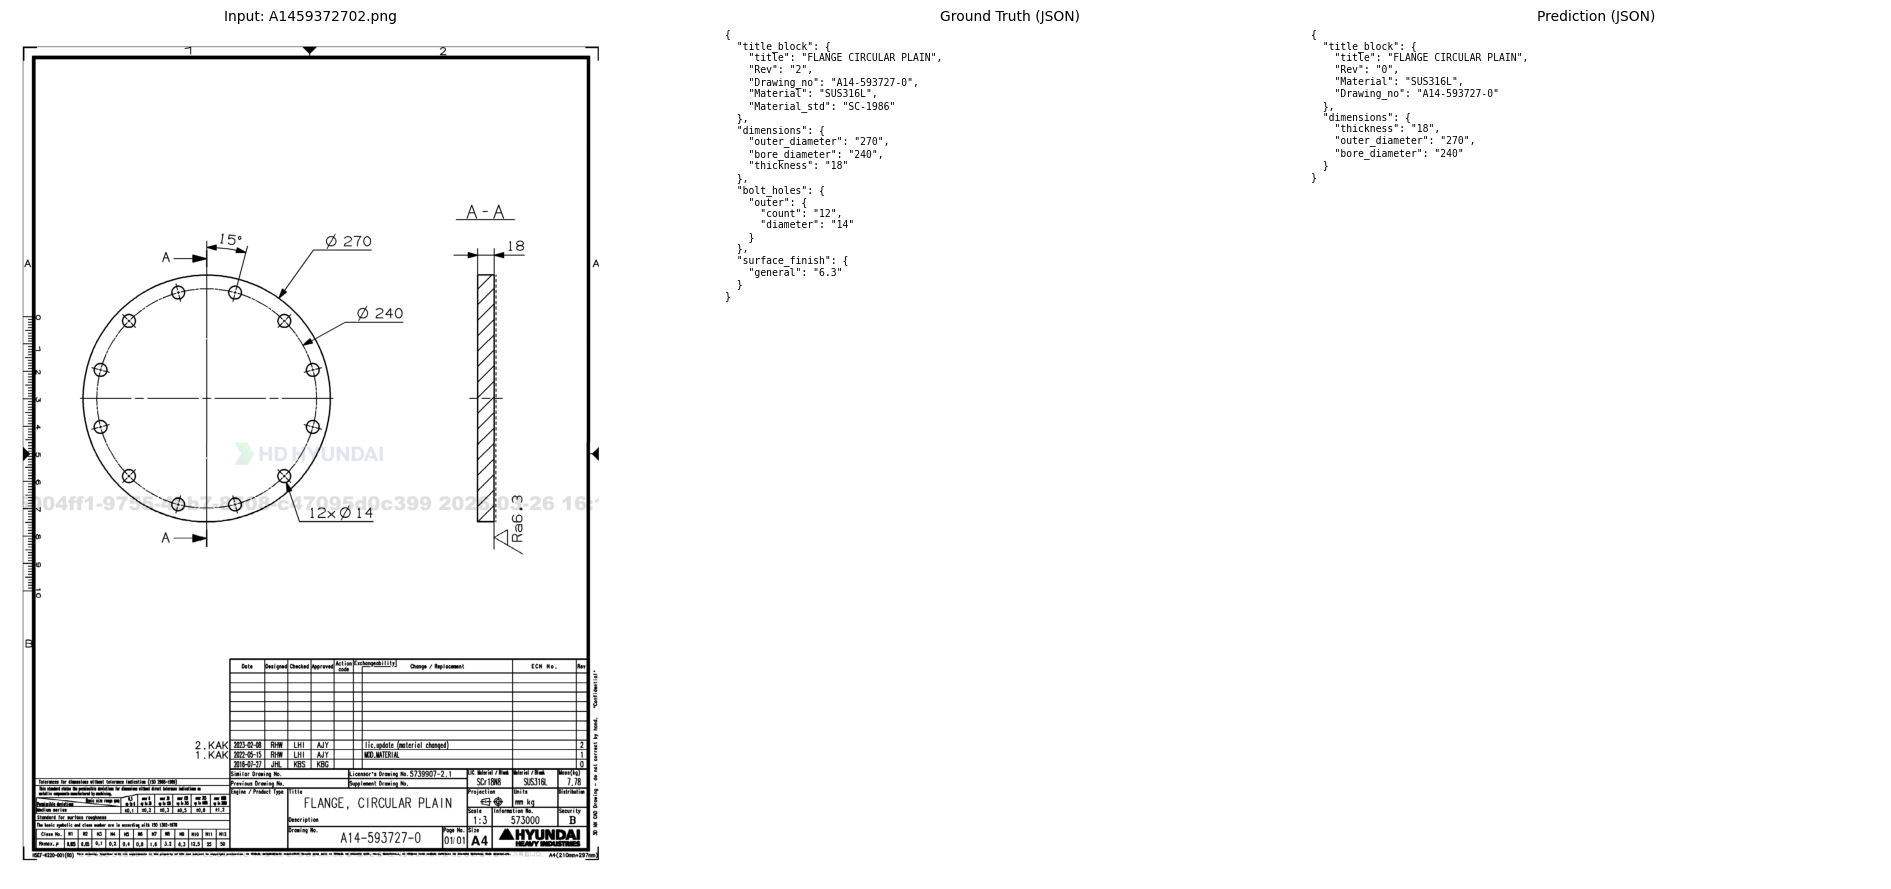

In [27]:
# ── Step 6: 단일 이미지 추론 (학습 재실행 불필요 · 단독 실행 가능) ────────
# 이 셀은 "이미 저장된 best 모델"을 디스크에서 바로 불러와 추론합니다.
#   · 커널을 재시작했어도, 학습(Step 4)을 다시 돌리지 않고 이 셀 하나만 실행하면 됩니다.
#   · best 모델 = checkpoints_drawings/final  — 학습 시 load_best_model_at_end=True 로
#     eval_loss 최저 체크포인트가 final/ 에 저장됩니다. checkpoint-* 폴더에는 프로세서
#     (tokenizer)가 없어 단독 추론에 쓸 수 없으므로 final/ 을 우선 사용합니다.
# ※ 그래프/콘솔 출력 문자열은 영어로 통일 — matplotlib 한글 글리프 의존을 없애 단순화.
import os, glob, re, json, textwrap
from pathlib import Path
import torch
from PIL import Image
import matplotlib.pyplot as plt
from transformers import DonutProcessor, VisionEncoderDecoderModel

# ── 설정: CFG(Step 1)가 있으면 사용, 없으면 기본값으로 동작 (셀 단독 실행 대비) ──
OUTPUT_DIR     = CFG["training"]["output_dir"] if "CFG" in globals() else "checkpoints_drawings"
TASK_PROMPT    = CFG["data"]["task_prompt"]    if "CFG" in globals() else "<s_drawing>"
MAX_NEW_TOKENS = CFG["model"]["max_length"]    if "CFG" in globals() else 768
VAL_DIR        = CFG["data"]["local_val_dir"]  if "CFG" in globals() else "data/processed_drawings/val"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def resolve_inference_dir(output_dir: str) -> str:
    """학습 재실행 없이 '추론에 바로 쓸' 모델 디렉터리를 찾습니다.
    (모델 가중치 + 프로세서/토크나이저 파일이 함께 있어야 단독 로드 가능)
      1순위: <output_dir>/final            — 학습 종료 시 best 모델 + 프로세서가 저장됨
      2순위: tokenizer.json 이 있는 checkpoint-* (스텝 큰 순서, 보통 없음)
    """
    cands = [os.path.join(output_dir, "final")]
    cands += sorted(glob.glob(os.path.join(output_dir, "checkpoint-*")),
                    key=lambda p: int(p.split("-")[-1]), reverse=True)
    for d in cands:
        if os.path.isdir(d) and os.path.isfile(os.path.join(d, "tokenizer.json")):
            return d
    raise FileNotFoundError(
        f"No usable inference model under output_dir={output_dir}.\n"
        f"  - <output_dir>/final is required (created once you run training Step 4 to the end).\n"
        f"  - checkpoint-* folders have no processor (tokenizer), so they can't be used alone."
    )


# 학습 결과(best 모델 + 프로세서)를 디스크에서 로드 — 여기서 학습은 일어나지 않습니다.
CKPT_DIR = resolve_inference_dir(OUTPUT_DIR)
eval_processor = DonutProcessor.from_pretrained(CKPT_DIR, use_fast=False)
eval_model     = VisionEncoderDecoderModel.from_pretrained(CKPT_DIR).to(device).eval()
print(f"Model loaded (best, no re-training) -> {CKPT_DIR}")

# token2json(Step 5a)이 없을 때를 대비한 폴백 정의 (Step 5a를 안 돌렸어도 동작)
if "token2json" not in globals():
    def token2json(tokens):
        output = {}
        while tokens:
            start = re.search(r"<s_(.+?)>", tokens)
            if not start:
                break
            key = start.group(1); end_pat = f"</s_{key}>"
            end_pos = tokens.find(end_pat, start.end())
            if end_pos == -1:
                break
            value = tokens[start.end():end_pos]
            if "<sep/>" in value:
                output[key] = [token2json(v) if "<s_" in v else v.strip()
                               for v in value.split("<sep/>")]
            elif "<s_" in value:
                output[key] = token2json(value)
            else:
                output[key] = value.strip()
            tokens = tokens[end_pos + len(end_pat):]
        return output if output else tokens.strip()


if "decode_tree" not in globals():   # Step 3a 를 안 돌렸을 때 폴백
    def decode_symbols(s):
        return re.sub(r"\s*U\+([0-9A-Fa-f]{4,6})\s*", lambda m: chr(int(m.group(1), 16)), str(s))
    def decode_tree(o):
        if isinstance(o, dict): return {k: decode_tree(v) for k, v in o.items()}
        if isinstance(o, list): return [decode_tree(v) for v in o]
        return decode_symbols(str(o))


@torch.inference_mode()
def predict(image_path: str, task: str | None = None,
            num_beams: int = 1, min_new_tokens: int = 0) -> dict:
    """이미지 경로 → 추출 정보(dict). task가 None이면 TASK_PROMPT 사용.

    기본은 greedy(num_beams=1). num_beams>1 이면 beam search 로 뒤쪽 섹션
    (bolt_holes 등) 누락은 줄지만, 현재 모델(데이터 ~50장)에선 중첩 구조가
    깨지거나 환각이 늘어 정밀도가 떨어질 수 있음 — 실험적으로만 사용.
    min_new_tokens 로 너무 이른 종료도 막을 수 있습니다(과한 값은 빈칸 생성 위험).
    """
    task = task or TASK_PROMPT
    image        = Image.open(image_path).convert("RGB")
    pixel_values = eval_processor(image, return_tensors="pt").pixel_values.to(device)
    decoder_ids  = eval_processor.tokenizer(
        task, add_special_tokens=False, return_tensors="pt"
    ).input_ids.to(device)

    outputs = eval_model.generate(
        pixel_values,
        decoder_input_ids = decoder_ids,
        max_new_tokens    = MAX_NEW_TOKENS,
        min_new_tokens    = min_new_tokens,
        num_beams         = num_beams,
        early_stopping    = num_beams > 1,
        pad_token_id      = eval_processor.tokenizer.pad_token_id,
        eos_token_id      = eval_processor.tokenizer.eos_token_id,
        use_cache         = True,
    )

    # 토큰 ID → 문자열 → (BOS/EOS/PAD/task 토큰 제거) → dict
    sequence = eval_processor.batch_decode(outputs, skip_special_tokens=False)[0]
    for t in (eval_processor.tokenizer.eos_token, eval_processor.tokenizer.pad_token,
              eval_processor.tokenizer.bos_token, task):
        if t:
            sequence = sequence.replace(t, "")
    parsed = token2json(sequence.strip())
    return decode_tree(parsed) if isinstance(parsed, dict) else decode_symbols(str(parsed))


# ── 데모: 검증셋(val) 이미지 한 장으로 추론 ──────────────────────
# 일관성을 위해 추론 대상은 *항상 검증셋(val)*에서만 고릅니다.
#   · val 은 학습에 쓰지 않은 이미지 → 일반화 성능을 보는 올바른 대상
#   · 특정 도면을 보려면 TARGET_IMG 만 바꾸세요. None 이면 val 첫 이미지를 사용합니다.
TARGET_IMG   = "A1459372702.png"    # 검증셋 내 파일명, 또는 None (→ val 첫 이미지)
val_imgs_dir = os.path.join(VAL_DIR, "images")
val_cands    = sorted(glob.glob(os.path.join(val_imgs_dir, "*")))
assert val_cands, f"검증셋 이미지가 없습니다: {val_imgs_dir} (먼저 train/val 분리 셀을 실행하세요)"
if TARGET_IMG:
    _hit = glob.glob(os.path.join(val_imgs_dir, TARGET_IMG))
    if not _hit:
        print(f"[경고] 검증셋에 {TARGET_IMG} 없음 → val 첫 이미지로 폴백")
    test_image_path = _hit[0] if _hit else val_cands[0]
else:
    test_image_path = val_cands[0]

result = predict(test_image_path)
print(f"\nInput: {test_image_path}")
print("Prediction:")
print(json.dumps(result, indent=2, ensure_ascii=False))

# ── 정답(GT) 로드: val 라벨에서 같은 stem 의 JSON 을 읽어 비교용으로 표시 ──
# 모델은 *단순화된* val 라벨(N/A·롱테일 키 제거본)을 학습했으므로, 같은 파일을 GT로
# 보여줘야 추론과 사과 대 사과로 비교됩니다.
stem    = Path(test_image_path).stem
gt_path = os.path.join(VAL_DIR, "labels", stem + ".json")
if os.path.isfile(gt_path):
    gt = json.loads(Path(gt_path).read_text(encoding="utf-8"))
    print("\nGround truth:")
    print(json.dumps(gt, indent=2, ensure_ascii=False))
else:
    gt = None
    print(f"\n[경고] 정답 라벨 없음: {gt_path}")

# ── 결과 저장: 입력 도면 + 정답(GT) + 추론 JSON 을 한 장의 PNG로 ────────
# 출력 파일 경로 — 필요하면 OUTPUT_PATH 만 바꾸세요.
OUTPUT_PATH = Path("output") / "output.png"
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

def _fmt_json(obj, fail_prefix=""):
    """dict면 보기 좋게, None이면 안내, 그 외(파싱 실패)는 원문을 안전하게.
    긴 한 줄이 figure 폭을 늘리지 않도록 60자에서 줄바꿈하고 길이를 제한합니다."""
    if isinstance(obj, dict):
        txt = json.dumps(obj, indent=2, ensure_ascii=False)
    elif obj is None:
        txt = "(no label found)"
    else:
        txt = fail_prefix + str(obj)
    if len(txt) > 4000:
        txt = txt[:4000] + "\n... (truncated)"
    return "\n".join(textwrap.fill(ln, width=60) for ln in txt.splitlines())

gt_text   = _fmt_json(gt)
pred_text = _fmt_json(result, "[parse failed - raw model output]\n")

# 입력 도면 | 정답(GT) | 추론 결과 — 3단 비교
fig, axes = plt.subplots(1, 3, figsize=(20, 9),
                         gridspec_kw={"width_ratios": [1.4, 1, 1]})
axes[0].imshow(Image.open(test_image_path).convert("RGB"))
axes[0].axis("off")
axes[0].set_title(f"Input: {os.path.basename(test_image_path)}", fontsize=10)

axes[1].axis("off")
axes[1].set_title("Ground Truth (JSON)", fontsize=10)
axes[1].text(0.0, 1.0, gt_text,
             transform=axes[1].transAxes, fontsize=7,
             va="top", ha="left", fontfamily="monospace")

axes[2].axis("off")
axes[2].set_title("Prediction (JSON)", fontsize=10)
axes[2].text(0.0, 1.0, pred_text,
             transform=axes[2].transAxes, fontsize=7,
             va="top", ha="left", fontfamily="monospace")   # 출력이 영어라 monospace 안전
plt.tight_layout()
fig.savefig(OUTPUT_PATH, dpi=150)   # 파일 저장 (show보다 먼저!) — bbox_inches 미사용으로 폭 고정
print(f"\nSaved result image -> {OUTPUT_PATH.resolve()}")
plt.show()                          # 노트북 인라인 표시

## 추론 결과를 JSON 형식으로 출력

모델이 생성한 **원시 토큰 문자열**(raw output)을 정리 → dict → 보기 좋은 JSON 문자열로 변환합니다.

> ⚠️ **학습이 부족하면** 토큰 구조가 깨져(예: `<___read>`, `<s/_read>`) 정상 JSON이 나오지 않습니다.
> 이 경우 아래 함수는 파싱 가능한 부분만 JSON으로 만들고, 실패하면 `_raw`에 원문을 담아 안전하게 보여줍니다.
> **깨진 출력 자체를 고치려면 파서가 아니라 추가 학습이 필요합니다.**


> 🔹 **추론 결과 → JSON 변환** — 특수/태스크 토큰 제거 후 dict 파싱·출력

In [28]:
# ── 추론 결과 → JSON 변환/출력 ──────────────
# 모델 원시 출력 문자열을 받아 JSON 문자열로 변환합니다.
# token2json(Step 5a) · eval_processor(Step 5b/6)가 먼저 정의돼 있어야 합니다.
import json, re

def output_to_json(raw: str, task_prompt: str = None, indent: int = 2) -> str:
    """모델 원시 출력 문자열 → JSON 문자열.

    1) 특수 토큰(BOS/EOS/PAD)과 task 토큰 제거
    2) token2json으로 <s_key>...</s_key> 구조를 dict로 파싱
    3) 파싱 실패(구조 손상) 시 {"_raw": ...}로 원문을 감싸 반환
    """
    task_prompt = task_prompt or CFG["data"]["task_prompt"]
    s = raw
    try:
        for t in (eval_processor.tokenizer.eos_token, eval_processor.tokenizer.pad_token,
                  eval_processor.tokenizer.bos_token):
            if t:
                s = s.replace(t, "")
    except Exception:
        pass
    s = s.replace(task_prompt, "").strip()

    parsed = token2json(s)
    if not isinstance(parsed, dict) or not parsed:
        parsed = {"_raw": raw.strip(),
                  "_note": "토큰 구조가 불완전합니다 — 학습 부족일 수 있습니다."}
    else:
        parsed = decode_tree(parsed)   # "U+XXXX" → 실제 글리프 복원
    return json.dumps(parsed, indent=indent, ensure_ascii=False)


# ── 사용법 A) 모델 원시 출력 문자열을 직접 변환 ──────────────
# generate() 직후 batch_decode로 얻은 문자열을 그대로 넣으세요.
raw_output = "<s_drawing><s_title_block><s_title> FLANGE</s_title> ...붙여넣기... </s_title_block>"
print(output_to_json(raw_output))

# ── 사용법 B) 이미지로 추론한 결과를 JSON으로 출력 ──────────────
# predict()는 이미 dict를 반환하므로 그대로 json.dumps 하면 됩니다.
# Step 6에서 고른 검증셋 이미지(test_image_path)를 그대로 재사용 → 두 셀이 항상 같은
# 이미지를 봅니다. 이 셀만 단독 실행했다면 폴백으로 val 첫 이미지를 사용합니다.
if "test_image_path" not in globals():
    import os, glob
    _vd = CFG["data"]["local_val_dir"] if "CFG" in globals() else "data/processed_drawings/val"
    test_image_path = sorted(glob.glob(os.path.join(_vd, "images", "*")))[0]
result = predict(test_image_path)
print(f"Input: {test_image_path}")
print(json.dumps(result, indent=2, ensure_ascii=False))


[transformers] Both `max_new_tokens` (=768) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


{
  "title_block": {
    "title": "FLANGE"
  }
}
Input: data/processed_drawings/val/images/A1459372702.png
{
  "title_block": {
    "title": "FLANGE CIRCULAR PLAIN",
    "Rev": "0",
    "Material": "SUS316L",
    "Drawing_no": "A14-593727-0"
  },
  "dimensions": {
    "thickness": "18",
    "outer_diameter": "270",
    "bore_diameter": "240"
  }
}


### (선택) 태그 없이 깔끔하게 출력

파싱 결과(dict)의 값에 `</s_...>`·`<sep/>` 같은 **잔여 태그**가 섞여 있으면 제거하고 보여줍니다.
(학습이 잘 되면 보통 깨끗하지만, 불완전 출력일 때 유용)


> 🔹 **태그 제거 후 출력** — 결과 내 <...> 태그를 모두 제거한 깔끔한 JSON 출력

In [20]:
# ── 태그 제거 후 출력 ──────────────
import re, json
from pprint import pprint

def strip_tags(o):
    """dict/list/str 안의 <...> 태그(<s_..>, </s_..>, <sep/>)를 모두 제거"""
    if isinstance(o, dict):
        return {k: strip_tags(v) for k, v in o.items()}
    if isinstance(o, list):
        return [strip_tags(v) for v in o]
    if isinstance(o, str):
        return re.sub(r"<[^>]*>", "", o).strip()
    return o

clean = strip_tags(result)   # result = Step 6 / 위 셀의 predict() 결과
print(json.dumps(clean, indent=2, ensure_ascii=False))   # 한글 유지 — JSON 권장
# pprint(clean, indent=2, width=80, compact=False)        # pprint를 원하면 이 줄 사용

# <sep/>를 구분 기호로 살리고 싶으면 strip_tags의 re.sub를 아래로 교체:
#   return re.sub(r"<(?!sep/>)[^>]*>", "", o).replace("<sep/>", ", ").strip()


{
  "title_block": {
    "title": "SP.FLANGE",
    "Rev": "0",
    "Material_std": "SC-1986",
    "Material": "SUS316L",
    "Drawing_no": "A14-636074-7"
  },
  "surface_finish": {
    "general": "12.5"
  },
  "dimensions": {
    "thickness": "14",
    "outer_diameter": "120",
    "bore_diameter": "34.5"
  },
  "bolt_holes": {
    "outer": {
      "pcd": "95",
      "diameter": "15",
      "count": "4"
    }
  }
}


---
## 도면 파인튜닝 체크리스트 & 트러블슈팅

### 실행 순서 요약
1. **Step 0 ~ 공통 import** 실행
2. **Step 1 (CFG)** — 그대로 실행 (도면용으로 이미 설정됨)
3. **라벨 점검** — 빈 값 비율 확인, 가능한 한 라벨을 채운다
4. **데이터 분리** — `data/processed_drawings/{train,val}` 생성
5. **Step 2 ~ 3** — 모델/데이터셋 로드 (`<s_drawing>` 토큰 자동 추가 확인)
6. **Step 4** — 학습 (`checkpoints_drawings/`에 저장)
7. **Step 5 ~ 6** — 평가 및 추론

### 자주 겪는 문제
| 증상 | 원인 | 해결 |
|------|------|------|
| 출력이 빈 값/엉뚱한 값 | 라벨에 빈 값이 많음, 데이터 부족 | 라벨 채우기, 데이터 추가, 에폭↑ |
| `eval_loss`가 다시 증가 | 과적합 (데이터 적을 때 흔함) | `load_best_model_at_end`가 최적 모델 복원 / 에폭↓ / 데이터↑ |
| 작은 글자 인식 실패 | 입력 해상도 부족 | `image_size`를 키움 (VRAM↑) |
| CUDA out of memory | 배치/해상도 과다 | `batch_size=1`, `gradient_accumulation_steps`↑ |
| 생성이 중간에 잘림 | `max_length` 부족 | `max_length`↑ (최대 768) |

### 데이터 양에 따른 권장 설정
- ~50장: `num_epochs 100`, 과적합 주의, 결과는 PoC 수준
- 수백 장: `num_epochs 50~80`
- 수천 장: `num_epochs 10~30`

> 핵심은 **라벨 품질과 스키마 일관성**입니다. 모든 라벨 JSON의 키 구조를 동일하게 유지하세요.


---
## 추론 결과 성능이 좋지 않은 이유와 해결방안

> 현재 베이스라인(도면 1장 → JSON, full-page Donut)에서 추론 품질이 낮습니다.
> **코드/파이프라인 문제가 아니라 데이터 규모·해상도·접근법의 한계**가 원인입니다.

### 1. 진단 — 무엇이 관측되었나
- **심한 과적합**: `train_loss ≈ 0.05`까지 떨어지는데 `eval_loss`는 `step≈1000`에서 `0.436`을 찍고 더 내려가지 않고 오히려 상승(최종 `0.451`). → train 45장을 *암기*했지만 val에는 일반화 실패. (위 **학습 곡선** 셀에서 두 곡선이 벌어지는 것으로 확인)
- **반복 붕괴(degeneration)**: greedy 디코딩 시 미수렴 디코더가 `<s_bolt_holes><s_count></s_count>` 같은 토큰을 EOS 없이 무한 반복 → `token2json` 파싱 실패.
- **값은 못 읽고 스키마만 외움**: 키 구조(`title_block`, `dimensions` …)는 나오지만 실제 값(`SUS316L` → `SUS16`)은 틀림.

### 2. 근본 원인 (영향 큰 순)
| # | 원인 | 설명 |
|---|------|------|
| 1 | **데이터 부족** | 학습 45장 / 검증 5장. 구조화 추출 학습엔 2~3 자릿수 부족. (가장 큰 원인) |
| 2 | **해상도·가독성** | A4 도면을 `1280×960`으로 축소하면 `Ø270`, `12x∅14` 등 치수 글자가 몇 픽셀로 뭉개져 인코더가 못 읽음. |
| 3 | **도메인 격차 (파인튜닝으로 *부분만* 메워짐)** | `donut-base`는 영수증/일반 문서로 사전학습. **파인튜닝이 바로 이 격차를 메우려는 시도**지만, 45장으로는 *디코더(출력 스키마·태그)*만 적응되고 *인코더(Swin)의 시각 인식*은 도면용으로 재학습되지 못함 → 키는 외우지만 값(`SUS316L`→`SUS16`)은 못 읽음. 즉 독립 원인이 아니라 **#1(데이터 부족)을 증폭**시키는 요인 — 격차가 클수록 더 많은 도면 데이터가 필요. |
| 4 | **라벨 희소성** | `N/A`·빈 값이 많아 "빈칸 보일러플레이트"를 학습. |
| 5 | **롱테일 스키마** | 1회만 등장하는 치수 키는 1샘플로 학습 불가. |
| 6 | **full-page 접근** | 도면 전체를 한 장으로 입력 → 1·2번 한계를 동시에 떠안음. |

### 3. 해결방안

#### A. 이미 이 노트북에 반영한 것
- **스키마 단순화** (데이터 분리 셀): `N/A`·빈 값 leaf 제거 + 롱테일 키 제거(`MIN_KEY_FREQ`). leaf 1172→723, 키 46→29종으로 축소해 모델이 외울 양을 줄임.
- **조기 종료** (`EarlyStoppingCallback`, patience=5): `eval_loss` 정체 시 자동 중단 + best 복원. 과적합 구간까지 학습하지 않음.
- **학습 곡선 시각화**: train vs eval loss로 과적합을 매 학습마다 눈으로 확인.

#### B. 다음으로 효과가 큰 것 (권장 우선순위)
1. **YOLO → Donut 요소 크롭 파이프라인으로 전환** — *가장 큰 레버*. 도면 전체가 아니라 **검출·정렬된 요소 크롭 1개 → 작은 값**을 인식. 해상도·도메인 문제를 한 번에 완화. (프로젝트 본 계획: `yolo_finetune_donut_pipeline/PLAN.md`)
2. **데이터 확충 + 증강** — 수백~수천 샘플. full-page라면 더더욱 필요. 회전/대비/노이즈 등 도면 친화 증강.
3. **입력 해상도 상향 / 타일링** — 글자 가독성 확보(`image_size` ↑ 또는 도면을 영역별로 잘라 입력). VRAM과 trade-off.
4. **라벨 품질·정규화** — 단위·표기 통일, 검수로 오라벨 제거(라벨 품질 = 모델 품질).
5. **검증셋 신뢰 주의** — val 5장은 지표 노이즈가 큼. 데이터가 늘면 val도 키울 것.

#### C. 임시 처치 (정확도는 못 고침, 증상만 완화)
- 추론 `generate(...)`에 `num_beams=4`, `no_repeat_ngram_size=3`, `repetition_penalty=1.3`를 주면 **반복 붕괴는 멈춤**(파싱은 되지만 내용 정확도는 그대로). 근본 해결은 A·B.

### 4. 한 줄 요약
> 코드는 정상. 품질은 **(1) 요소 크롭 파이프라인 전환 + (2) 데이터 확충**이 핵심이며,
> 그 전까지는 **스키마 단순화·조기 종료**로 과적합을 억제하고 **학습 곡선**으로 상태를 모니터링한다.